In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv(r"2023_songs_cleaned.csv")
df.head()

,track_id,track_name,track_artist,popularity_2023,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,instrumentalness,liveness,valence,tempo,duration_ms,popularity_2025,season,year,period,popularity_categorized
0,6ZMda6mscE8eRkuwlw8yFB,bedsitter,soft cell,18,1xza4j8vMQdGqqQdHa30lI,non stop erotic cabaret (deluxe edition),1981-12-18,"Maxi Pop GOLD (New Wave, Electropop, Synth Po...",2nRWtTI9a2LWjJ9Wy3JZs5,pop,...,0.00538,0.0747,0.610,145.271,215333,12,Autumn,1981,1980s,hardly recognizable
1,4GDmAT5ZZyHdBo32UYDIvM,tainted love,soft cell,53,1xza4j8vMQdGqqQdHa30lI,non stop erotic cabaret (deluxe edition),1981-12-18,Classic Rock Radio,4lIywN6kXl9KPm3OQ8u8G7,rock,...,0.00000,0.2920,0.651,144.543,153880,44,Autumn,1981,1980s,famous
2,4bnNwCbIo9vxlIpu88KV0K,der mussolini - 1998 - remaster,daf,2,2nQmZO698ZhHOkxUaCZPJS,alles ist gut,1981-03-18,Gothic / Industrial / Mittelalter / EBM / Futu...,53CmFroG6MWR5reOOXJX6B,pop,...,0.49400,0.1160,0.867,156.308,235107,0,Winter,1981,1980s,hardly recognizable
3,6KrMDGTp9CtkMLKyftDUTD,wavelength - remastered,van morrison,44,47nhRTYeYBKV5mEfXLV4fb,wavelength,1978-09-18,Classic Rock Retrogamer,6gUFdcGzKAHyDXY9TKC6cP,rock,...,0.00115,0.4630,0.522,142.829,346987,22,Summer,1978,1970s,hardly recognizable
4,3JXOMZdeJ7uMR7UfC3BN5T,top of the bill - live,scorpions,2,3fWEWigB3tgsGAUN4kNIKf,tokyo tapes (50th anniversary deluxe edition),1978-08-18,This Is Scorpions,37i9dQZF1DWViGKI2U5P2K,rock,...,0.67500,0.9130,0.232,142.665,407333,0,Summer,1978,1970s,hardly recognizable


In [3]:
df_grouped=pd.read_csv(r"songs_grouped_by_song.csv")
df_grouped.head()

,track_name,playlist_genre,track_album_name,playlist_subgenre,track_artist,duration_ms,popularity_2023,popularity_2025,track_album_release_date,danceability,...,liveness,valence,tempo,season,popularity_categorized,year,period,artist_avg_pop,release_age,artist_song_count
0,"""i tried for years... nobody listened""",rap,war,gangster rap,iceberg black,150909.0,18.0,0.0,2018-09-22,0.914,...,0.116,0.0944,140.0260,Autumn,hardly recognizable,2018,2010s,18.00,7,1
1,"""this is seagull….""",pop,smother earth,electropop,the snake corps,238227.0,34.0,35.0,1990-01-01,0.516,...,0.110,0.2350,135.9030,Winter,famous,1990,1990s,34.00,35,1
2,#1 stunna,rap,i got that work,hip hop; southern hip hop,big tymers,281960.0,24.0,25.5,2000-01-01,0.552,...,0.258,0.5650,89.0435,Winter,famous,2000,2000s,24.25,25,4
3,#nakama,r&b,#nakama,hip pop,xlii,192094.0,26.0,6.0,2019-12-25,0.797,...,0.318,0.5680,108.0410,Winter,hardly recognizable,2019,2010s,26.00,6,1
4,#natural,latin,#natural,latin hip hop,paty cantú,227013.0,50.0,33.0,2017-10-20,0.800,...,0.134,0.8160,97.0230,Autumn,famous,2017,2010s,56.50,8,2


In [4]:
#check data shape
print(f"The Number of Rows are {df_grouped.shape[0]}, and columns are {df_grouped.shape[1]}.")

The Number of Rows are 23052, and columns are 27.


In [27]:
#explore datatypes and null entries of each feature
df_grouped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23052 entries, 0 to 23051
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_name                23052 non-null  object 
 1   playlist_genre            23052 non-null  object 
 2   track_album_name          23052 non-null  object 
 3   playlist_subgenre         23052 non-null  object 
 4   track_artist              23052 non-null  object 
 5   duration_ms               23052 non-null  float64
 6   popularity_2023           23052 non-null  float64
 7   popularity_2025           23052 non-null  float64
 8   track_album_release_date  23052 non-null  object 
 9   danceability              23052 non-null  float64
 10  energy                    23052 non-null  float64
 11  key                       23052 non-null  int64  
 12  loudness                  23052 non-null  float64
 13  mode                      23052 non-null  int64  
 14  speech

PS: some of the songs within the dataset included only the year of release of the track, thus we weren't able to identify the season, hence the empty entries in the season column.

In [5]:
#fix date column datatype
df["track_album_release_date"]=pd.to_datetime(df["track_album_release_date"])
df_grouped["track_album_release_date"]=pd.to_datetime(df_grouped["track_album_release_date"])

In [29]:
#Check track genre distribution
df["playlist_genre"].value_counts().reset_index().head(10)

,playlist_genre,count
0,edm,6043
1,rap,5740
2,pop,5506
3,r&b,5411
4,latin,5152
5,rock,4910


In [30]:
# df_mod=df.copy()
# df_mod["playlist_genre"]=df_mod["playlist_genre"].str.split(";")
# df_mod=df_mod.explode("playlist_genre",ignore_index=True)
# df_mod["playlist_genre"]=df_mod["playlist_genre"].str.strip()

In [31]:
#Summary Analysis for numerical fearures
df.describe()

,popularity_2023,track_album_release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity_2025,year
count,32762.000000,32762,32762.000000,32762.000000,32762.000000,32762.000000,32762.000000,32762.000000,32762.000000,32762.000000,32762.000000,32762.000000,32762.000000,32762.000000,32762.000000,32762.000000
mean,42.471766,2011-09-07 18:23:40.133080832,0.655110,0.698876,5.375252,-6.711046,0.565320,0.107156,0.175007,0.084640,0.190149,0.510363,120.887909,225804.922502,25.990355,2011.221293
min,0.000000,1957-01-01 00:00:00,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000,0.000000,1957.000000
25%,24.000000,2008-09-23 00:00:00,0.563000,0.581000,2.000000,-8.161000,0.000000,0.041100,0.015000,0.000000,0.092700,0.330000,99.962000,187851.000000,0.000000,2008.000000
50%,45.000000,2016-09-01 00:00:00,0.672000,0.721000,6.000000,-6.162000,1.000000,0.062600,0.080000,0.000016,0.127000,0.512000,121.984000,216037.000000,18.000000,2016.000000
75%,62.000000,2019-04-19 00:00:00,0.761000,0.840000,9.000000,-4.643000,1.000000,0.132000,0.254000,0.004780,0.248000,0.693000,133.906250,253573.000000,50.000000,2019.000000
max,100.000000,2020-01-29 00:00:00,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000,92.000000,2020.000000
std,24.983101,NaN,0.144973,0.180784,3.612122,2.982411,0.495723,0.101365,0.219427,0.224146,0.154304,0.233159,26.895968,59784.103686,27.441439,11.269122


In [32]:
#Summary Analysis for categorical fearures
df.describe(include="object")

,track_id,track_name,track_artist,track_album_id,track_album_name,playlist_name,playlist_id,playlist_genre,playlist_subgenre,season,period,popularity_categorized
count,32762,32762,32762,32762,32762,32762,32762,32762,32762,30972,32762,32762
unique,28297,23052,10670,22492,19483,449,471,6,24,4,7,3
top,7BKLCZ1jbUBVqRi2FVlTVw,poison,martin garrix,5L1xcowSxwzFUSJzvyMp48,greatest hits,Indie Poptimism,4JkkvMpVl4lSioqQjeAL0q,edm,progressive electro house,Autumn,2010s,hardly recognizable
freq,10,22,161,42,139,308,247,6043,1809,9327,23993,16960


<Figure size 1200x900 with 0 Axes>

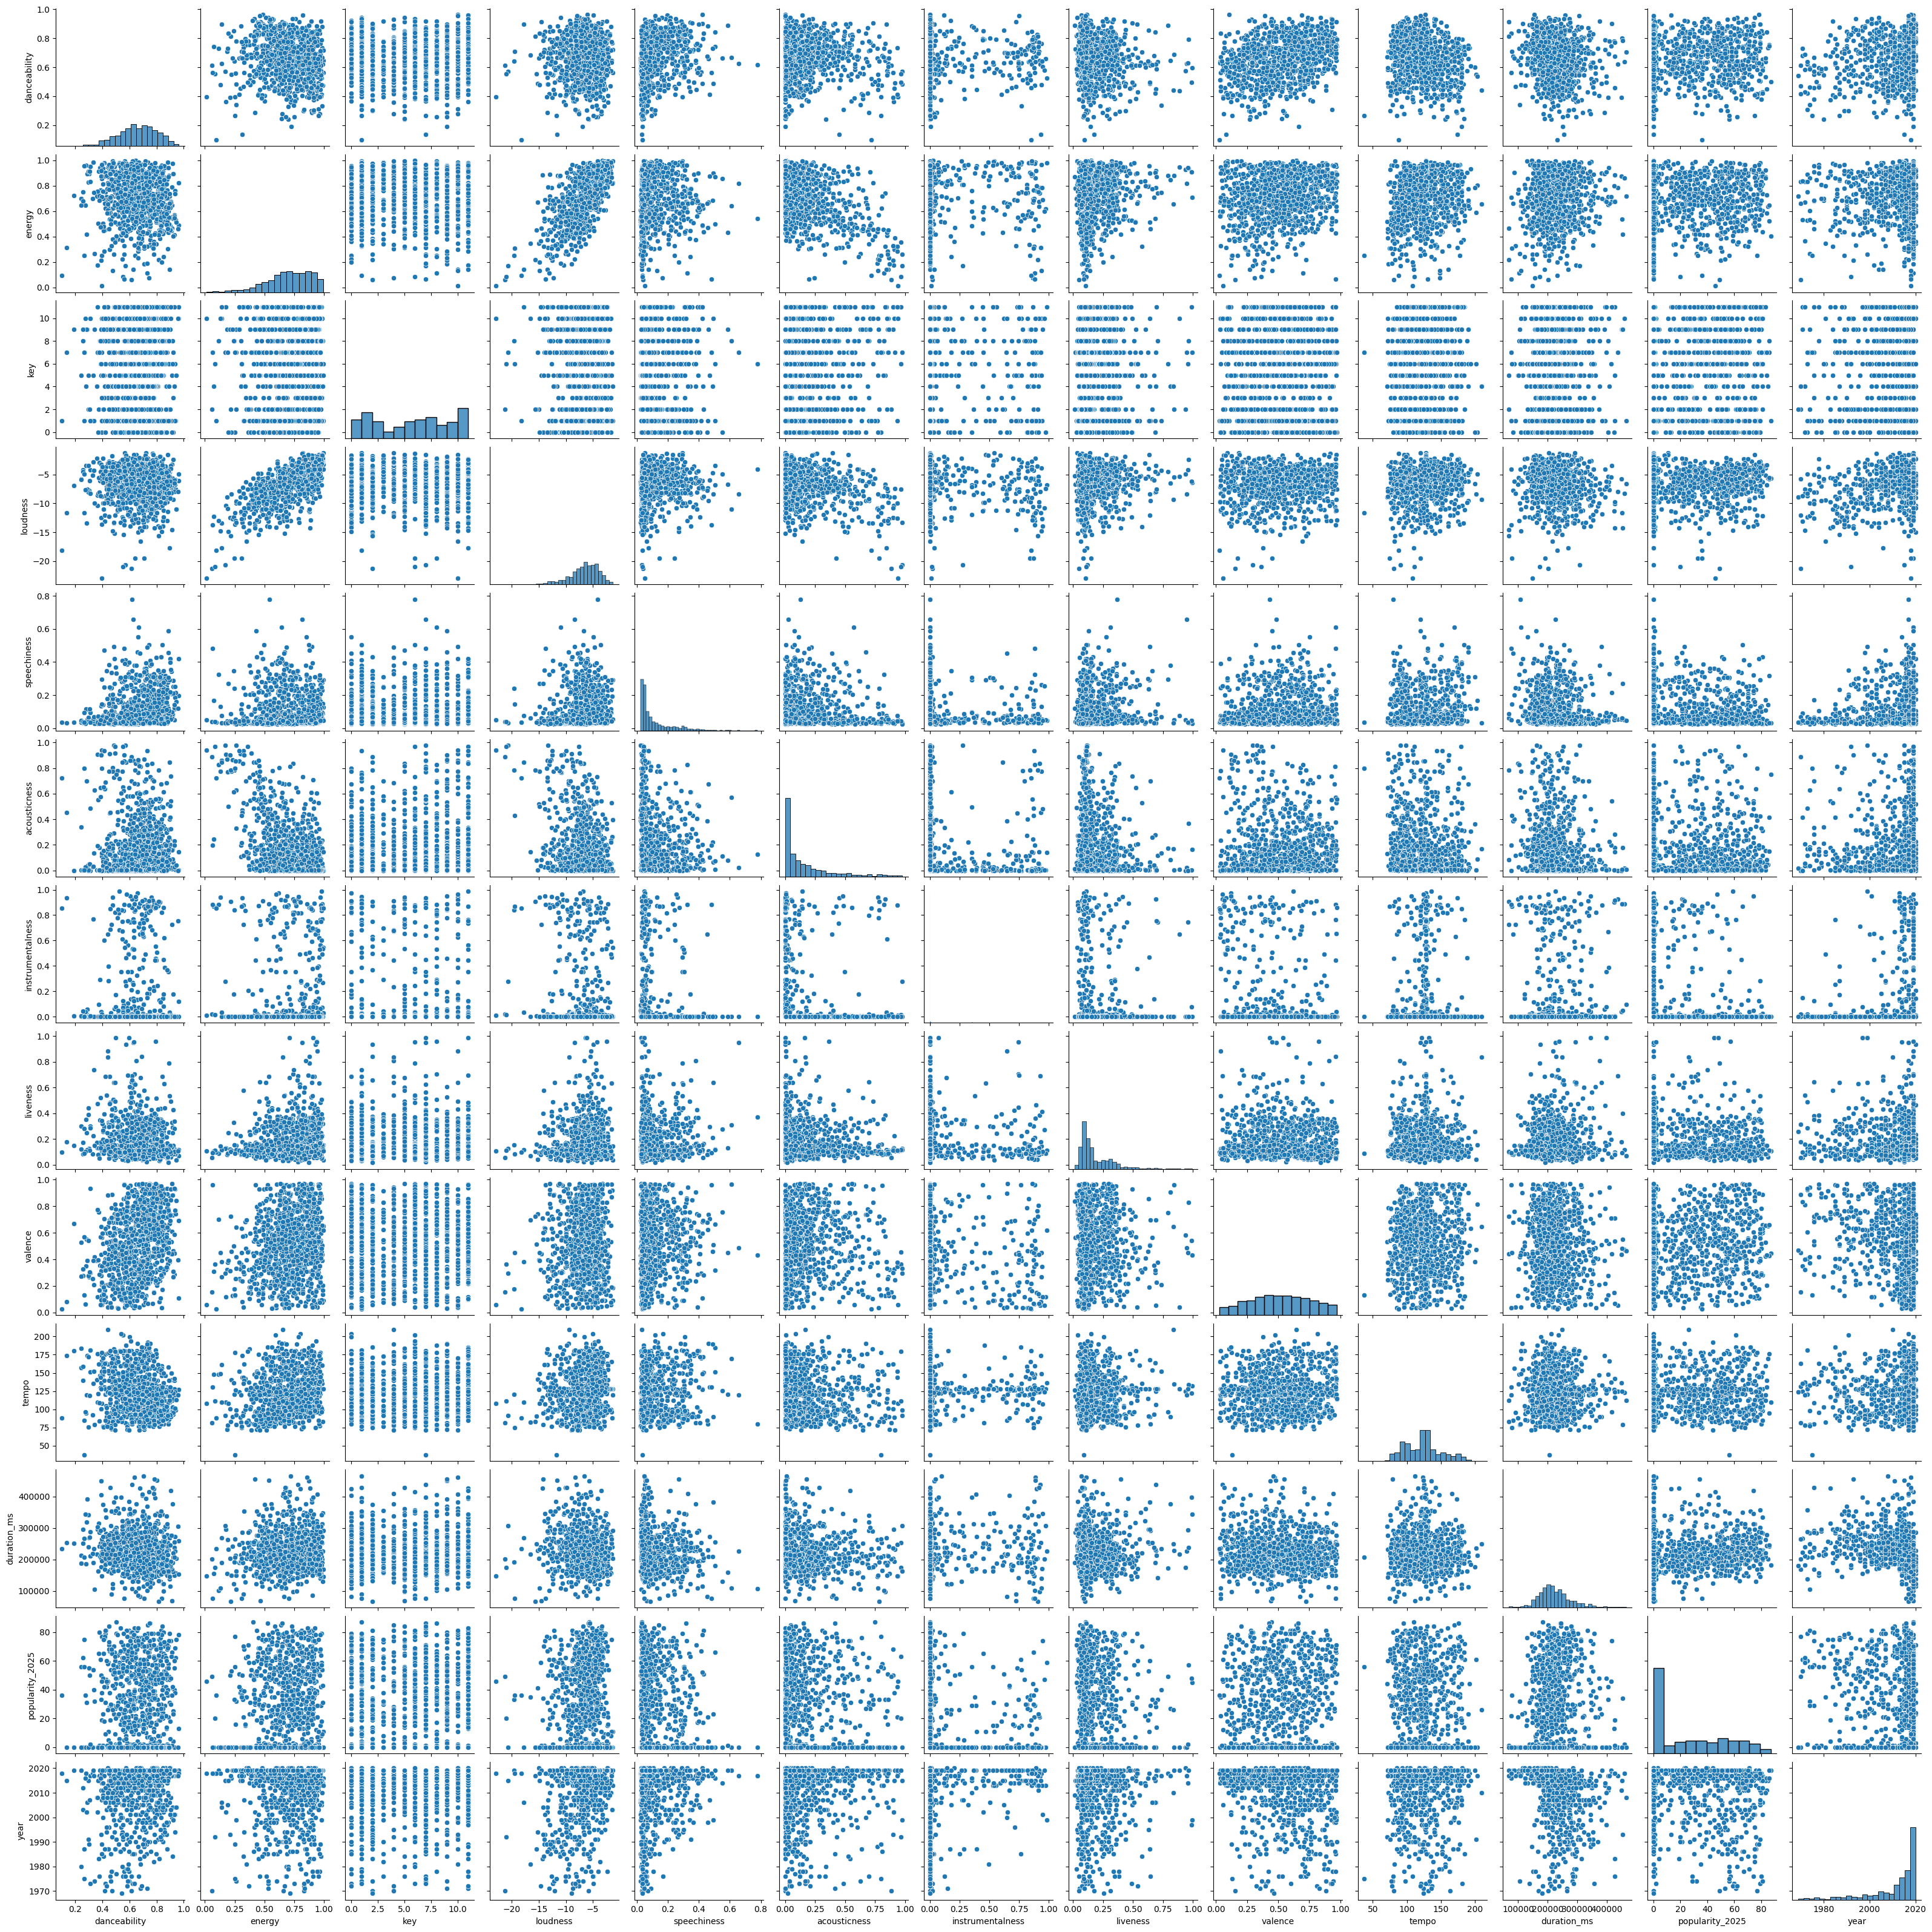

In [33]:
plt.figure(figsize=(12,9))
sns.pairplot(df.drop(columns=["mode","popularity_2023"]).sample(1000,replace=False),palette="viridis",)
plt.show()

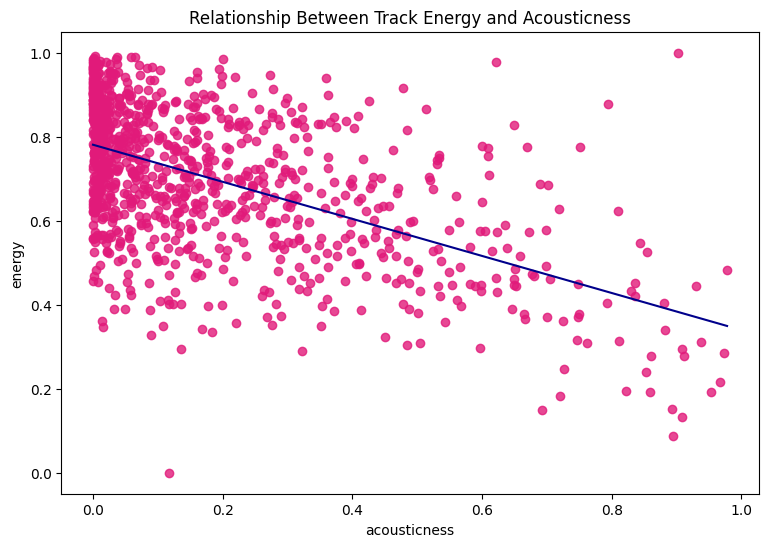

In [34]:
plt.figure(figsize=(9,6))
sns.regplot(df_grouped.sample(1000,random_state=420),x="acousticness",y="energy",line_kws={"color":"darkblue","linewidth":1.5},scatter_kws={"color":"#e11a7a"},ci=False)
plt.title("Relationship Between Track Energy and Acousticness")
plt.show()

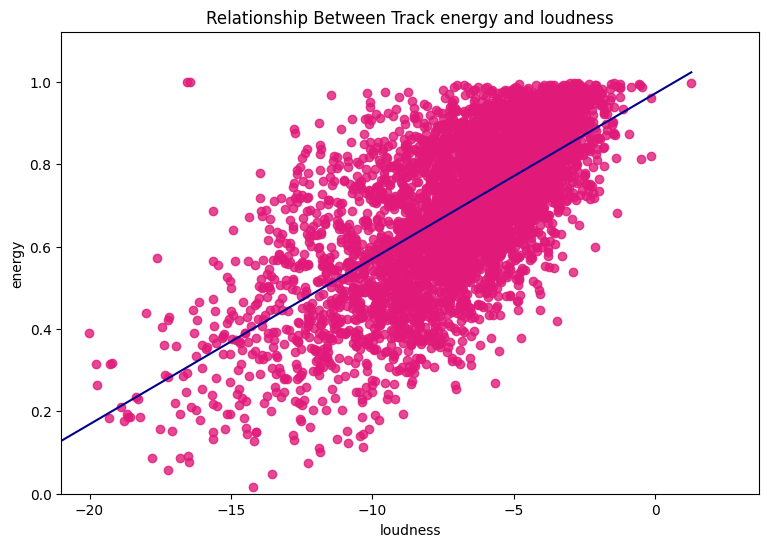

In [35]:
plt.figure(figsize=(9,6))
sns.regplot(df_grouped.sample(5000,random_state=420),x="loudness",y="energy",line_kws={"color":"darkblue","linewidth":1.5},scatter_kws={"color":"#e11a7a"},ci=False)
plt.title("Relationship Between Track energy and loudness")
plt.xlim(-21,)
plt.ylim(0,)
plt.show()

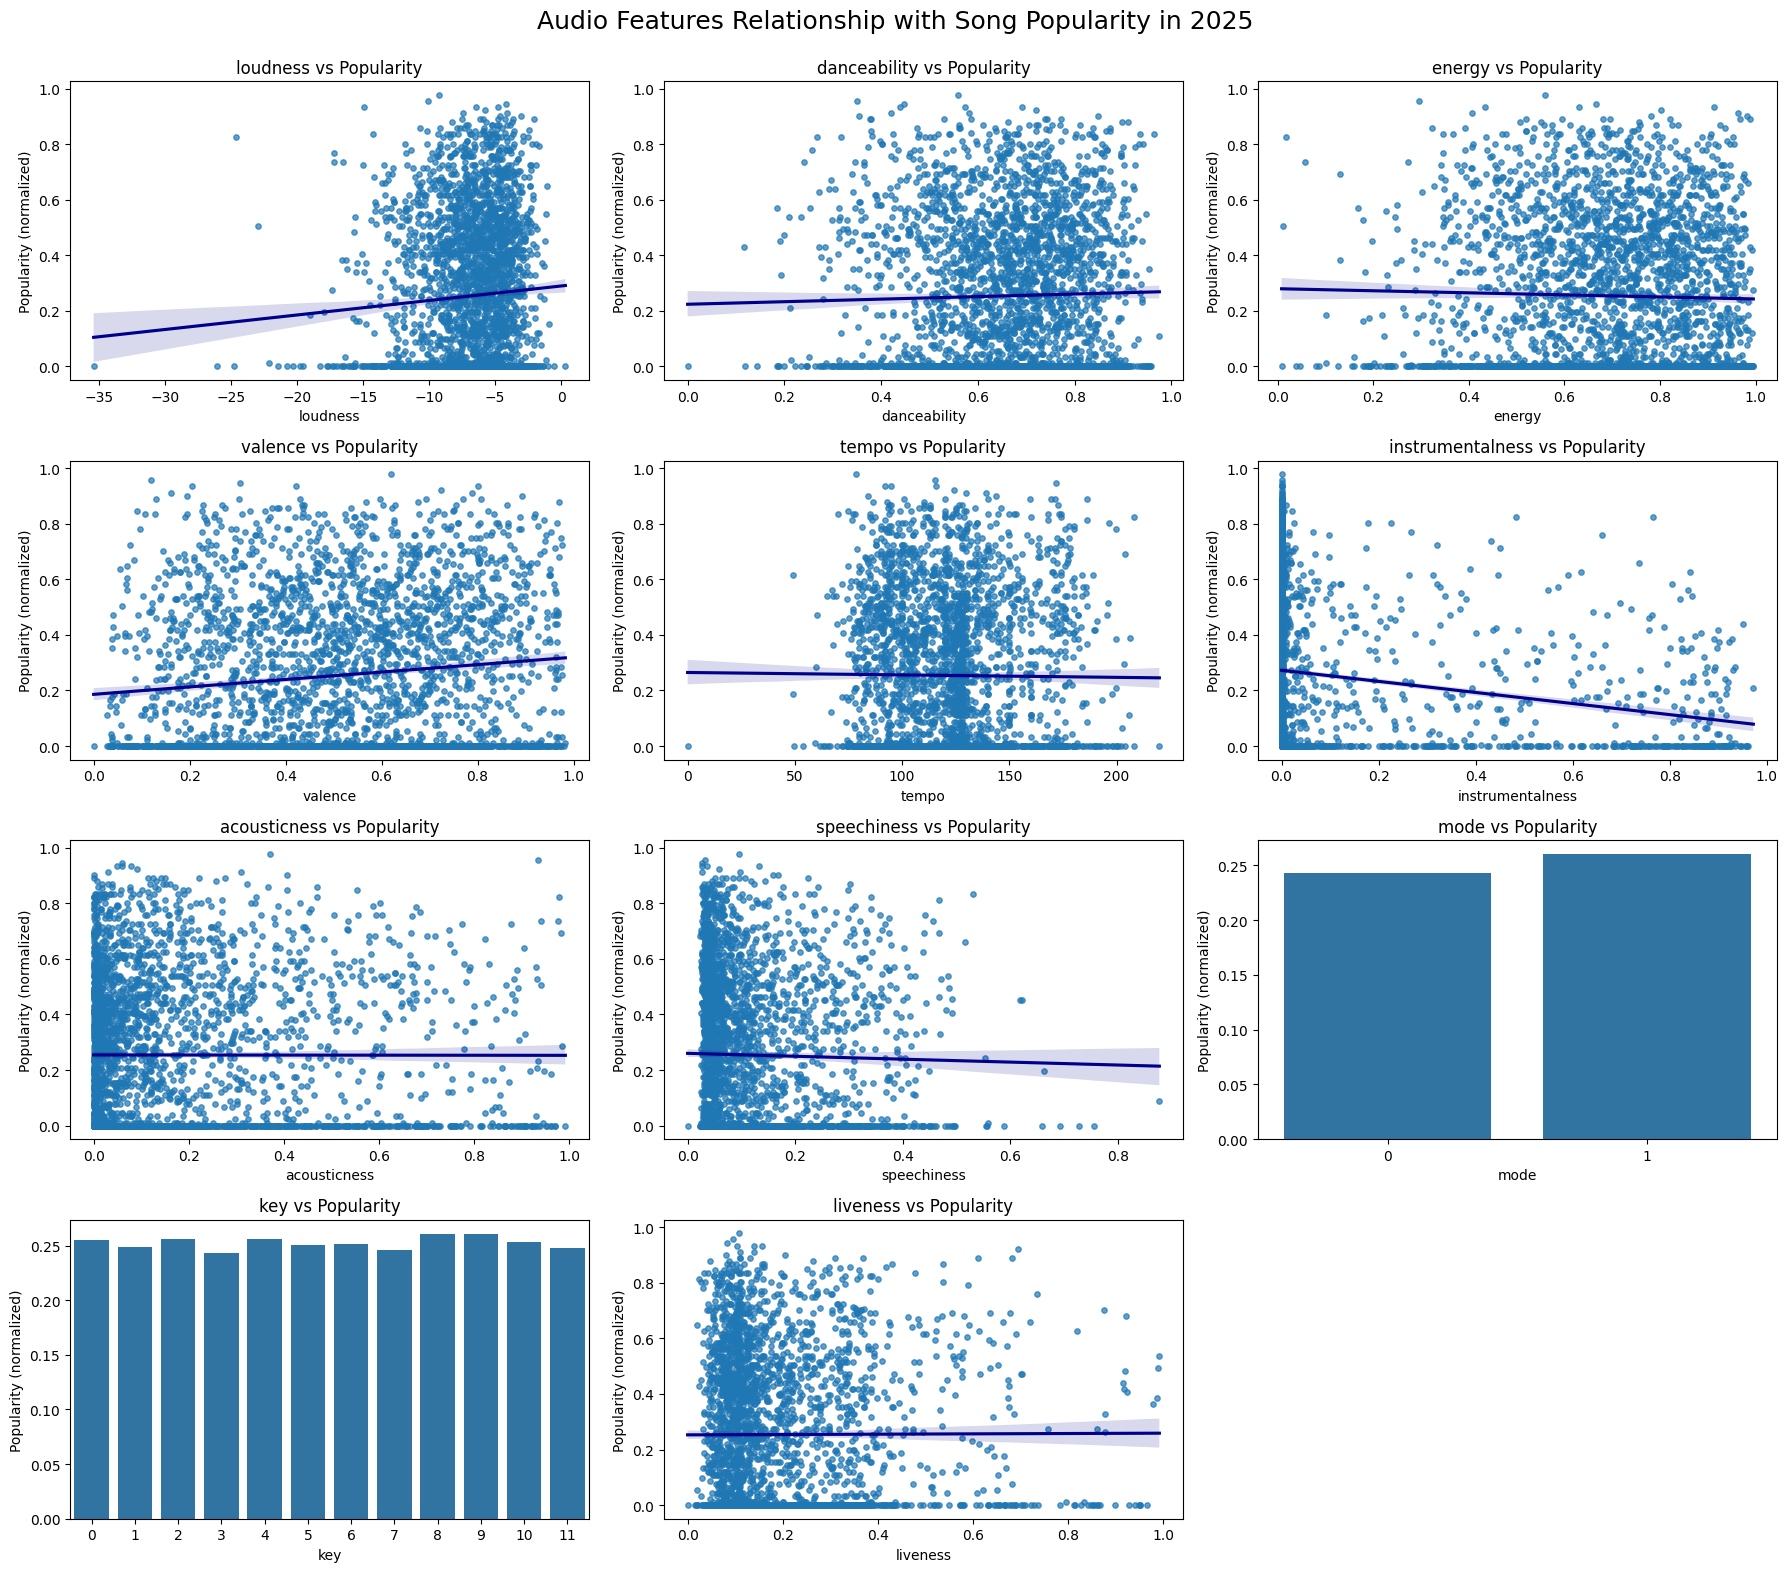

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select continuous features to compare with popularity
features = [
    "loudness", "danceability", "energy", "valence",
    "tempo", "instrumentalness", "acousticness",
    "speechiness", "mode", "key", "liveness"
]

# Normalize popularity to 0-1 for plotting if needed
df_grouped["popularity_norm"] = (df_grouped["popularity_2025"] - df_grouped["popularity_2025"].min()) / (df_grouped["popularity_2025"].max() - df_grouped["popularity_2025"].min())

n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()
for i, feature in enumerate(features):
    if feature=="key" or feature=="mode":
         sns.barplot(
              x=feature,
              y="popularity_norm",
              data=df_grouped,
              ax=axes[i],
              errorbar=None
         )
    else:
        sns.regplot(
            x=feature,
            y="popularity_norm",
            data=df_grouped.sample(3000,random_state=42),
            ax=axes[i],
            scatter_kws={"s": 15, "alpha": 0.7},
            line_kws={"color": "darkblue"}
        )

    axes[i].set_title(f"{feature} vs Popularity", fontsize=12)
    axes[i].set_ylabel("Popularity (normalized)")
    axes[i].set_xlabel(feature)

plt.suptitle("Audio Features Relationship with Song Popularity in 2025\n",fontsize=18)
# Hide any extra empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()


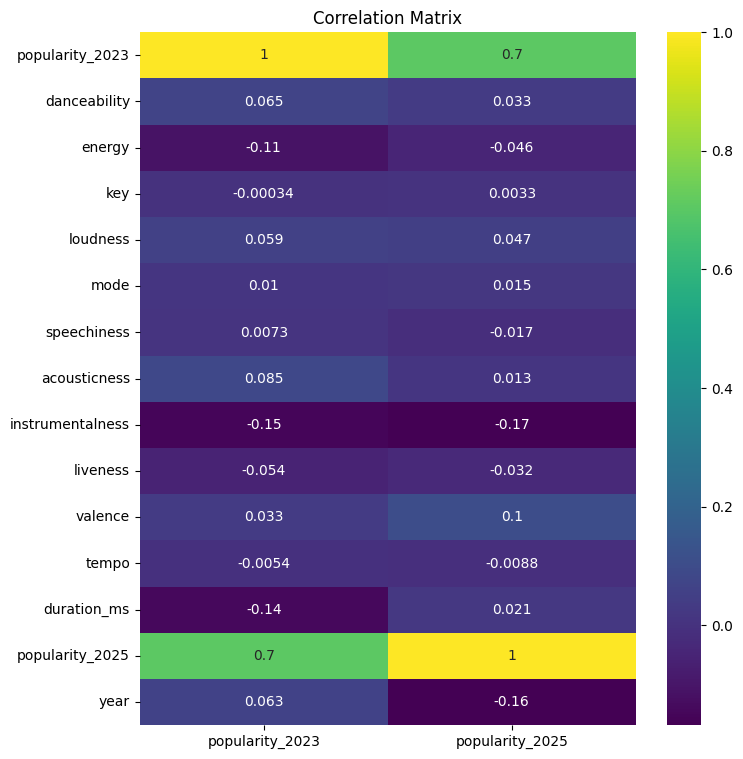

In [37]:
plt.figure(figsize=(8,9))
sns.heatmap(df.select_dtypes("number").corr()[["popularity_2023","popularity_2025"]],cmap="viridis",annot=True)
plt.title("Correlation Matrix")
plt.show()

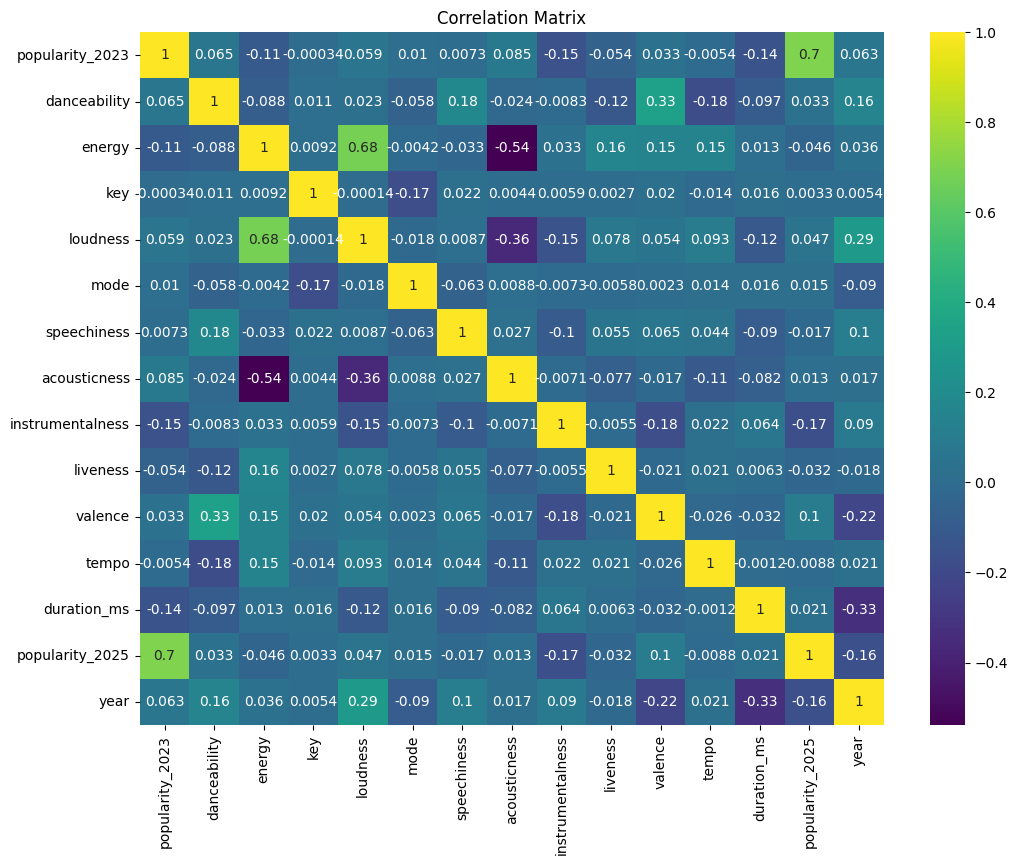

In [38]:
plt.figure(figsize=(12,9))
sns.heatmap(df.select_dtypes("number").corr(),cmap="viridis",annot=True)
plt.title("Correlation Matrix")

plt.show()

Check Numerical Columns Distribution

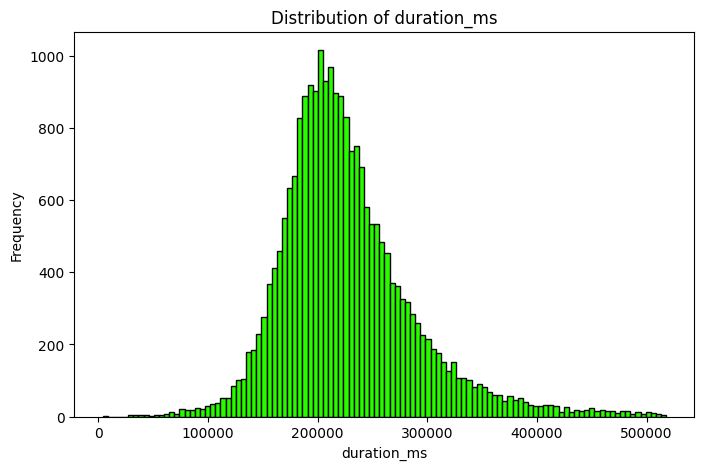

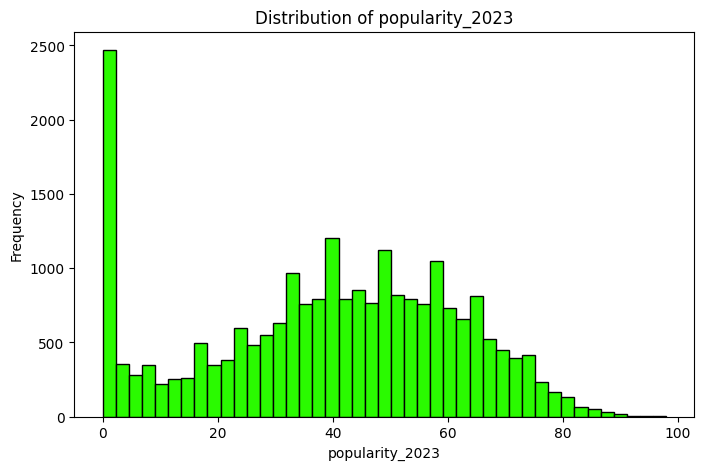

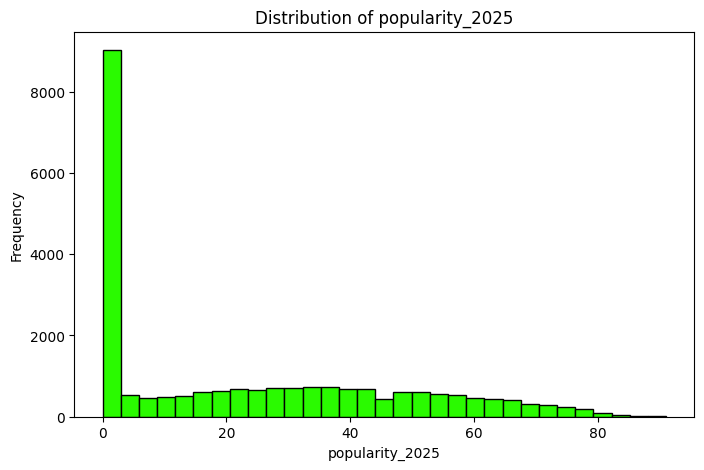

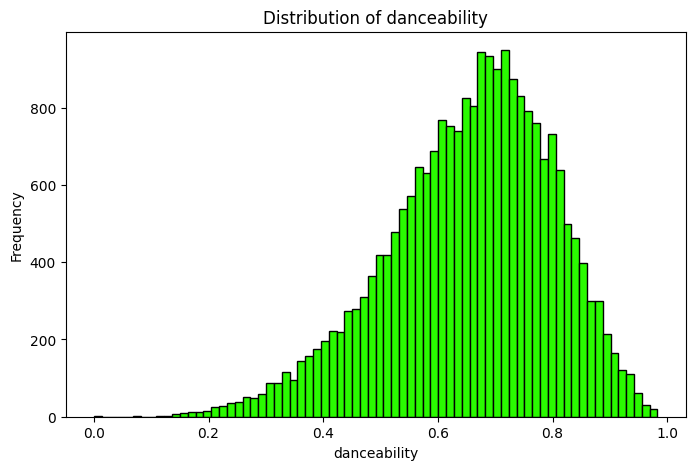

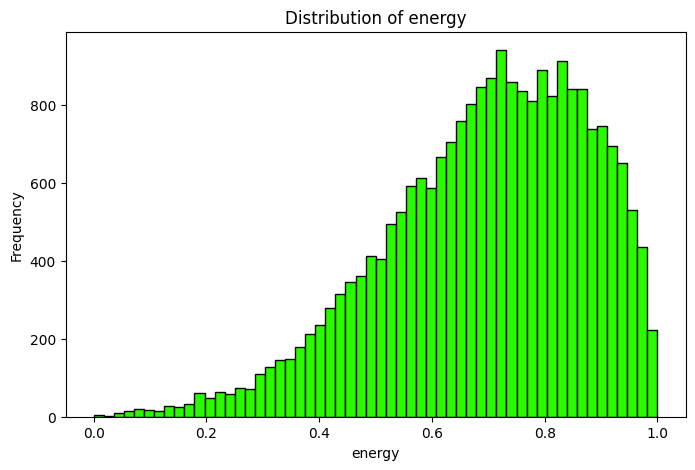

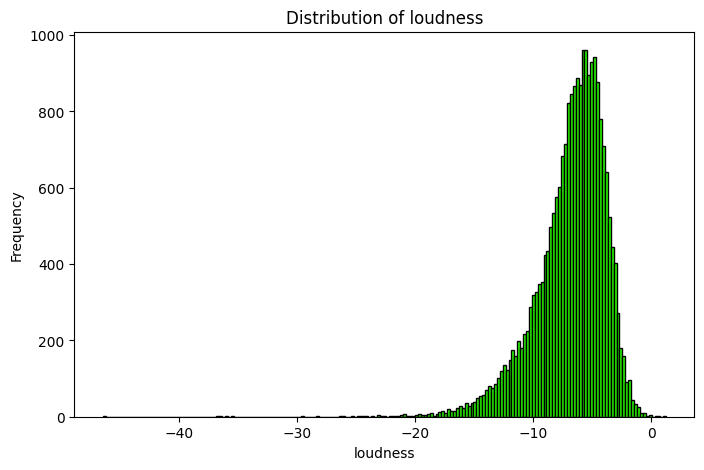

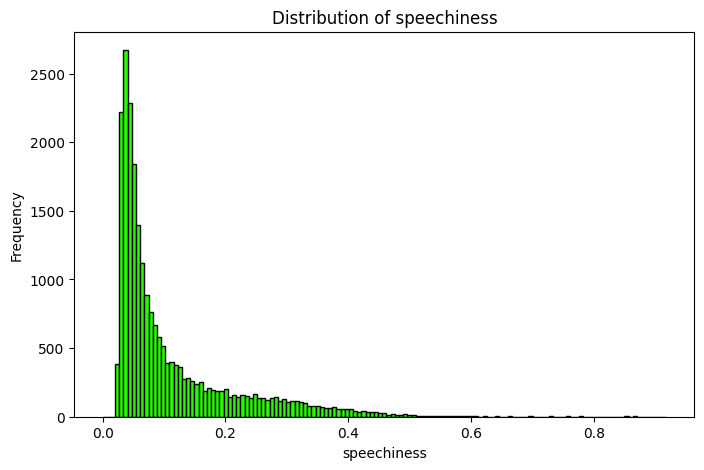

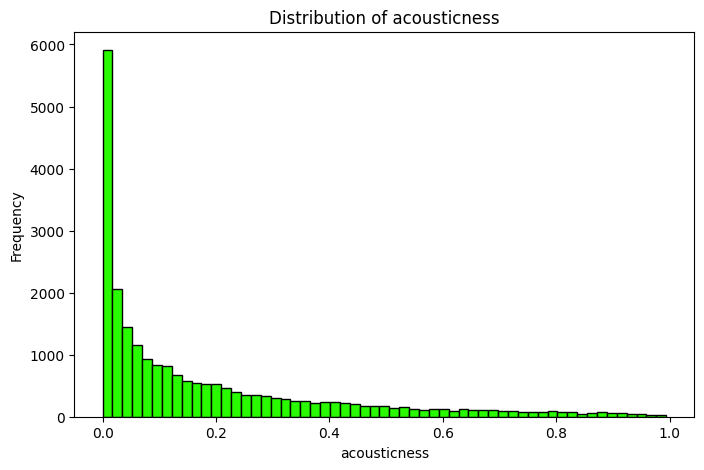

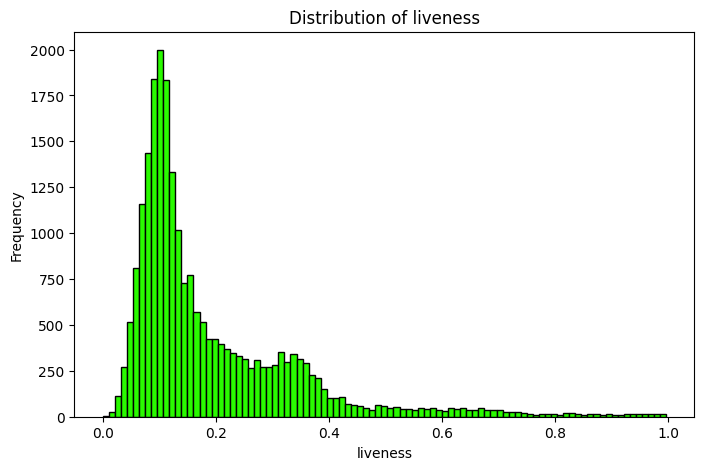

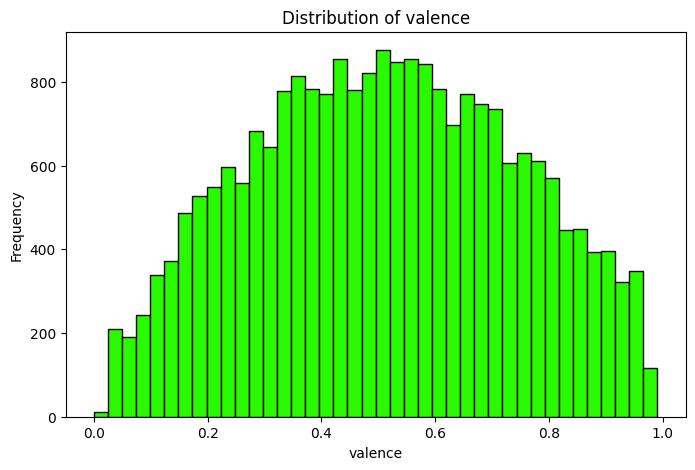

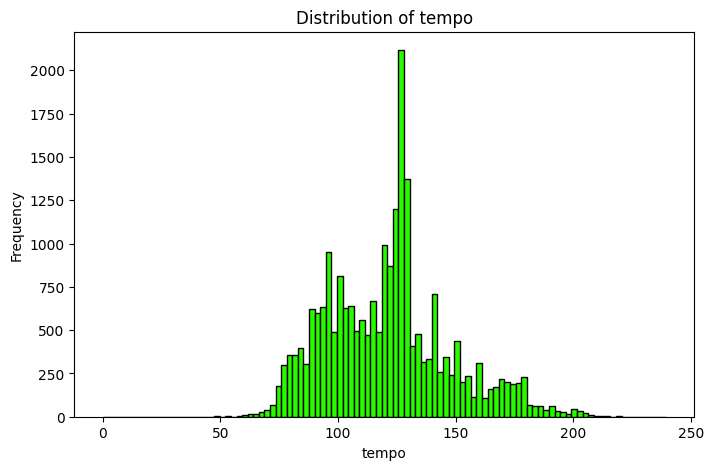

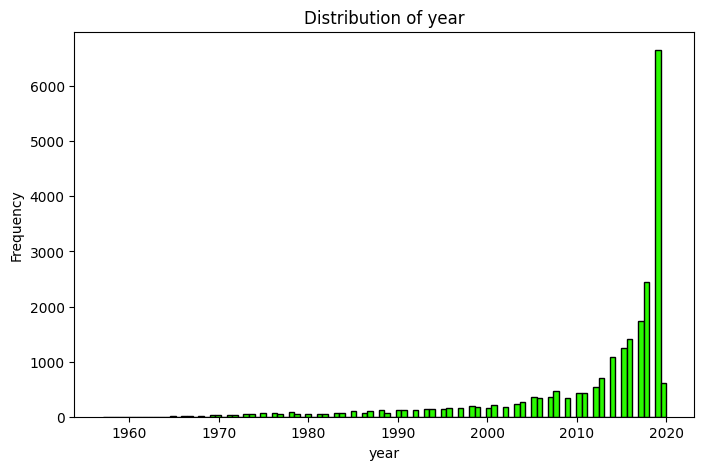

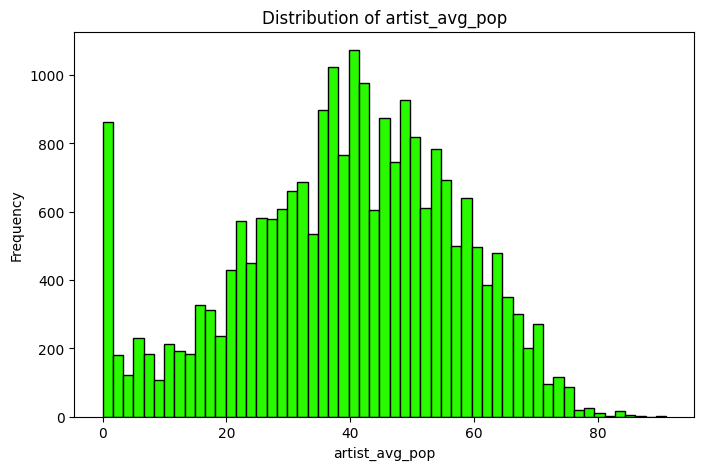

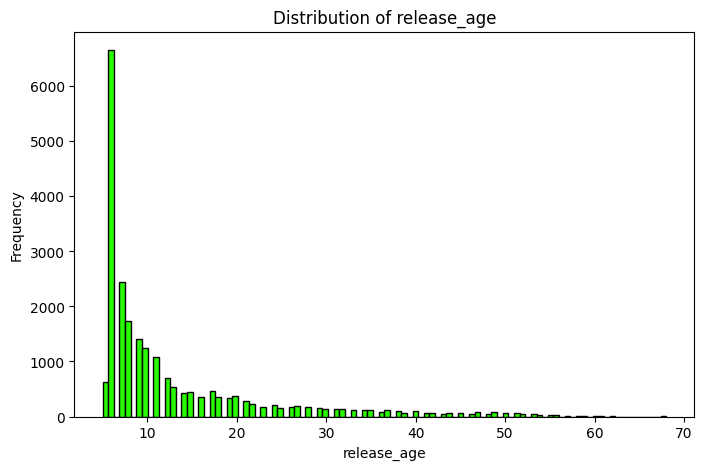

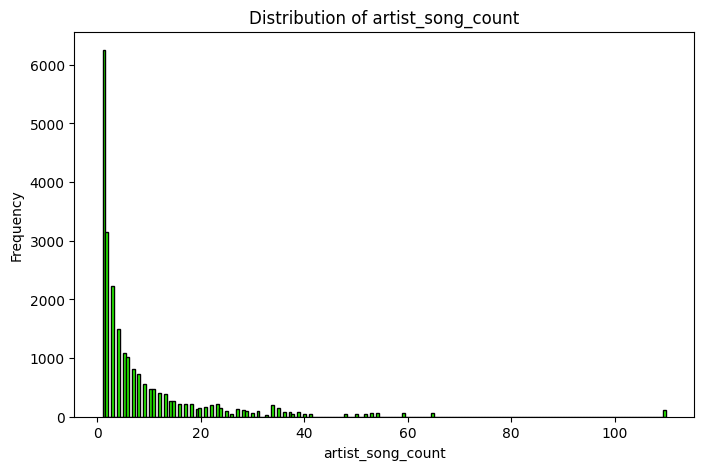

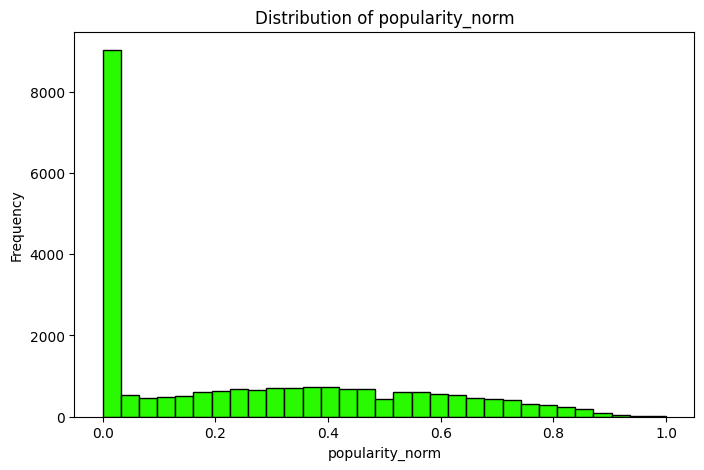

In [39]:
plt.rcParams["figure.figsize"] = (8, 5)

numerical_cols = df_grouped.select_dtypes("number").columns.tolist()
numerical_cols.pop(numerical_cols.index("key"))
numerical_cols.pop(numerical_cols.index("instrumentalness"))
numerical_cols.pop(numerical_cols.index("mode"))

for col in numerical_cols:
    plt.figure()
    
    # Freedman-Diaconis rule for bin width
    data = df_grouped[col].dropna()
    q75, q25 = np.percentile(data, [75 ,25])
    iqr = q75 - q25
    bin_width = 2 * iqr * (len(data) ** (-1/3))
    if bin_width == 0:
        bins = 10  # fallback if IQR is 0
    else:
        bins = int(np.ceil((data.max() - data.min()) / bin_width))
    
    # Plot histogram with adaptive bins
    plt.hist(data, bins=bins, edgecolor='black',color="#2afa00")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


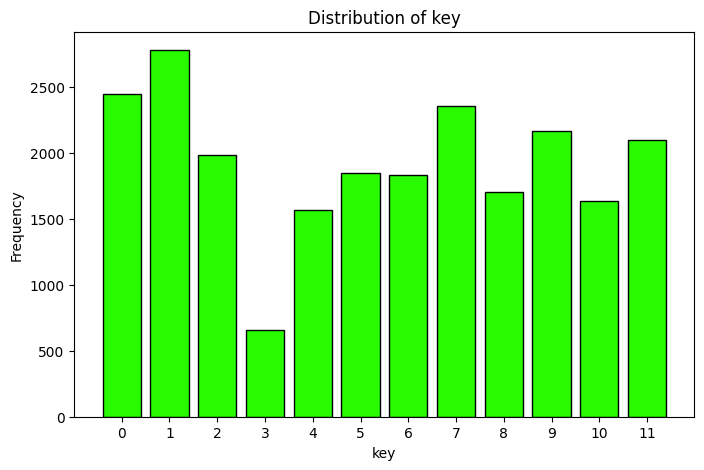

In [40]:
plt.figure()

data = df_grouped["key"].dropna()
# Make a bin for each integer
bins = np.arange(data.min() - 0.5, data.max() + 1.5, 1)

plt.hist(data, bins=bins, edgecolor='black', rwidth=0.8,color="#2afa00")  # rwidth controls bar width
plt.title(f"Distribution of key")
plt.xlabel("key")
plt.ylabel("Frequency")
plt.xticks(range(data.min(), data.max() + 1))  # show each integer on x-axis
plt.show()


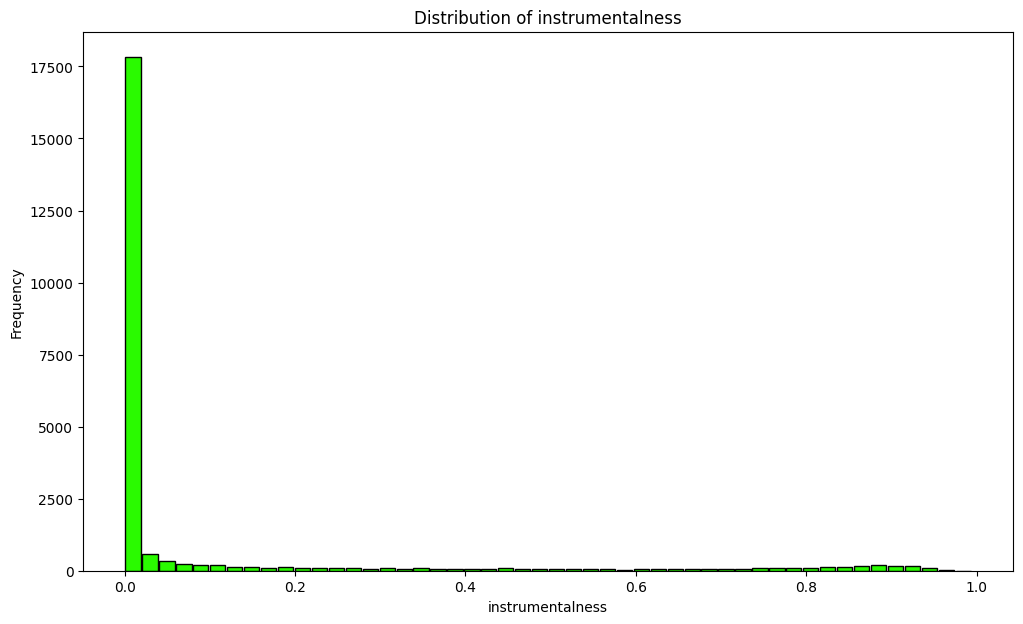

In [41]:
plt.figure(figsize=(12,7))
# Plot histogram with adaptive bins
plt.hist(df_grouped["instrumentalness"], bins=50, edgecolor='black',rwidth=.9,color="#2afa00")
plt.title(f"Distribution of {"instrumentalness"}")
plt.xlabel("instrumentalness")
plt.ylabel("Frequency")
plt.show()


Checking for Categorical columns distribution

In [42]:
df.select_dtypes("object").columns

Index(['track_id', 'track_name', 'track_artist', 'track_album_id',
       'track_album_name', 'playlist_name', 'playlist_id', 'playlist_genre',
       'playlist_subgenre', 'season', 'period', 'popularity_categorized'],
      dtype='object')

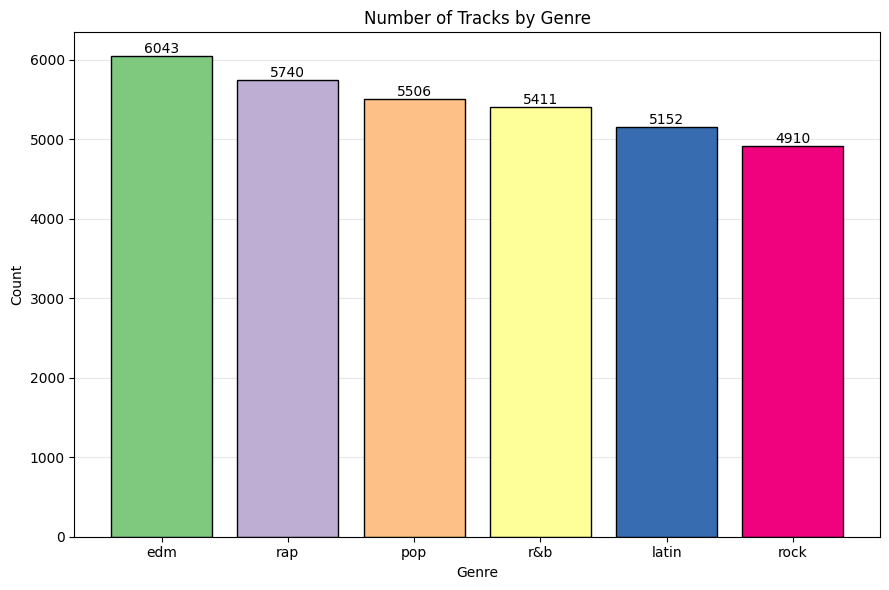

In [6]:
genre_count=df["playlist_genre"].value_counts()
plt.figure(figsize=(9,6))
colors=plt.cm.Accent(range(len(genre_count)))
bars=plt.bar(x=genre_count.index,height=genre_count.values,color=colors,zorder=2,edgecolor="k")
for bar in bars:
    height=bar.get_height()
    plt.text(
    bar.get_x() + bar.get_width() / 2,  # x-position (center of the bar)
    height + 0.5,                       # y-position (slightly above the bar)
    f"{int(height)}",                   # label text
    ha="center", va="bottom", fontsize=10
    )
plt.grid(True,axis="y",zorder=0,alpha=.3)
plt.title("Number of Tracks by Genre")
plt.ylabel("Count")
plt.xlabel("Genre")
plt.tight_layout()
plt.show()

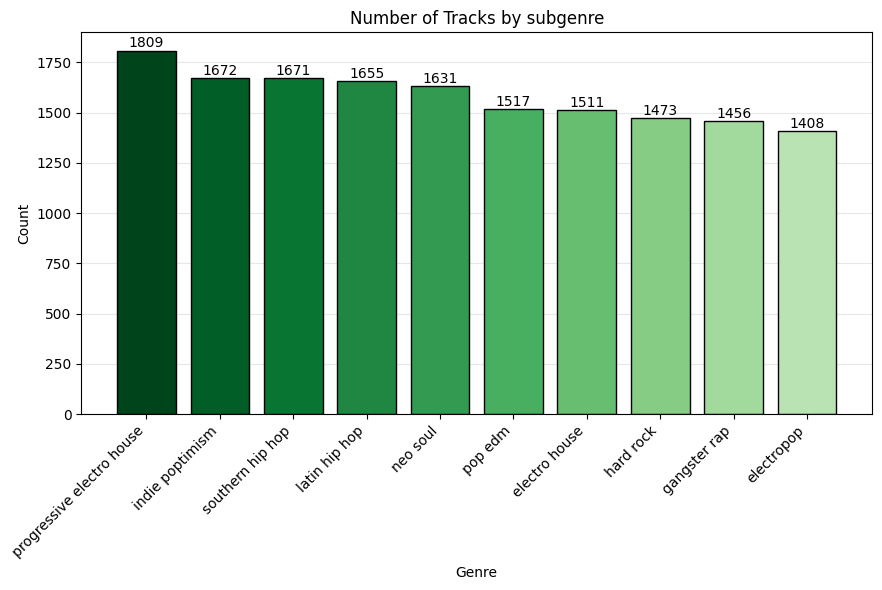

In [7]:
subgenre_count=df["playlist_subgenre"].value_counts().head(10)
plt.figure(figsize=(9,6))
colors=plt.cm.Greens_r(range(0,len(subgenre_count)*200,20))
bars=plt.bar(x=subgenre_count.index,height=subgenre_count.values,color=colors,zorder=2,edgecolor="k")
for bar in bars:
    height=bar.get_height()
    plt.text(
    bar.get_x() + bar.get_width() / 2,  # x-position (center of the bar)
    height + 0.5,                       # y-position (slightly above the bar)
    f"{int(height)}",                   # label text
    ha="center", va="bottom", fontsize=10
    )
plt.grid(True,axis="y",zorder=0,alpha=.3)
plt.title("Number of Tracks by subgenre")
plt.ylabel("Count")
plt.xlabel("Genre")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

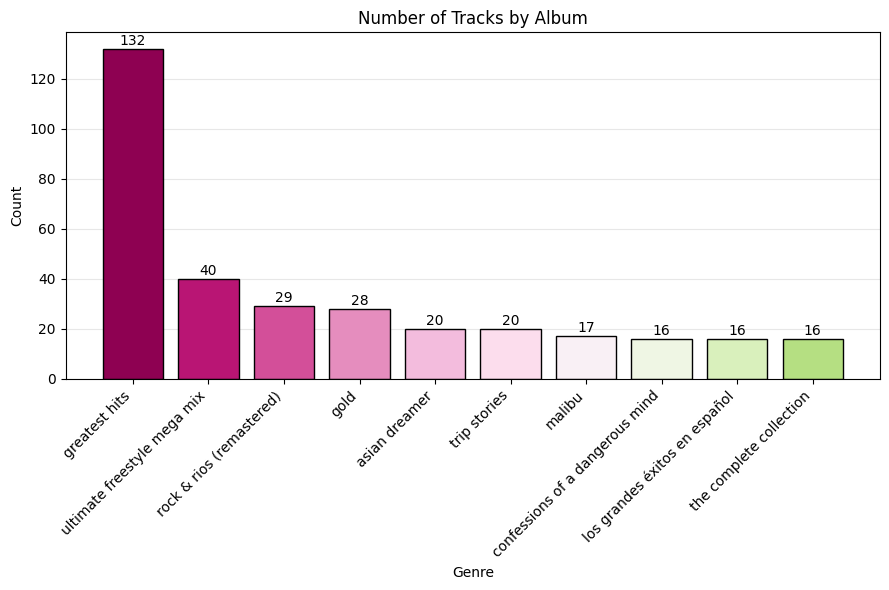

In [8]:
df_grouped1=df.groupby(["track_name","track_album_name"]).agg("count").reset_index()
album_count=df_grouped1["track_album_name"].value_counts().head(10)
plt.figure(figsize=(9,6))
colors=plt.cm.PiYG(range(0,len(album_count)*200,20))
bars=plt.bar(x=album_count.index,height=album_count.values,color=colors,zorder=2,edgecolor="k")
for bar in bars:
    height=bar.get_height()
    plt.text(
    bar.get_x() + bar.get_width() / 2,  # x-position (center of the bar)
    height + 0.5,                       # y-position (slightly above the bar)
    f"{int(height)}",                   # label text
    ha="center", va="bottom", fontsize=10
    )
plt.grid(True,axis="y",zorder=0,alpha=.3)
plt.title("Number of Tracks by Album")
plt.ylabel("Count")
plt.xlabel("Genre")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

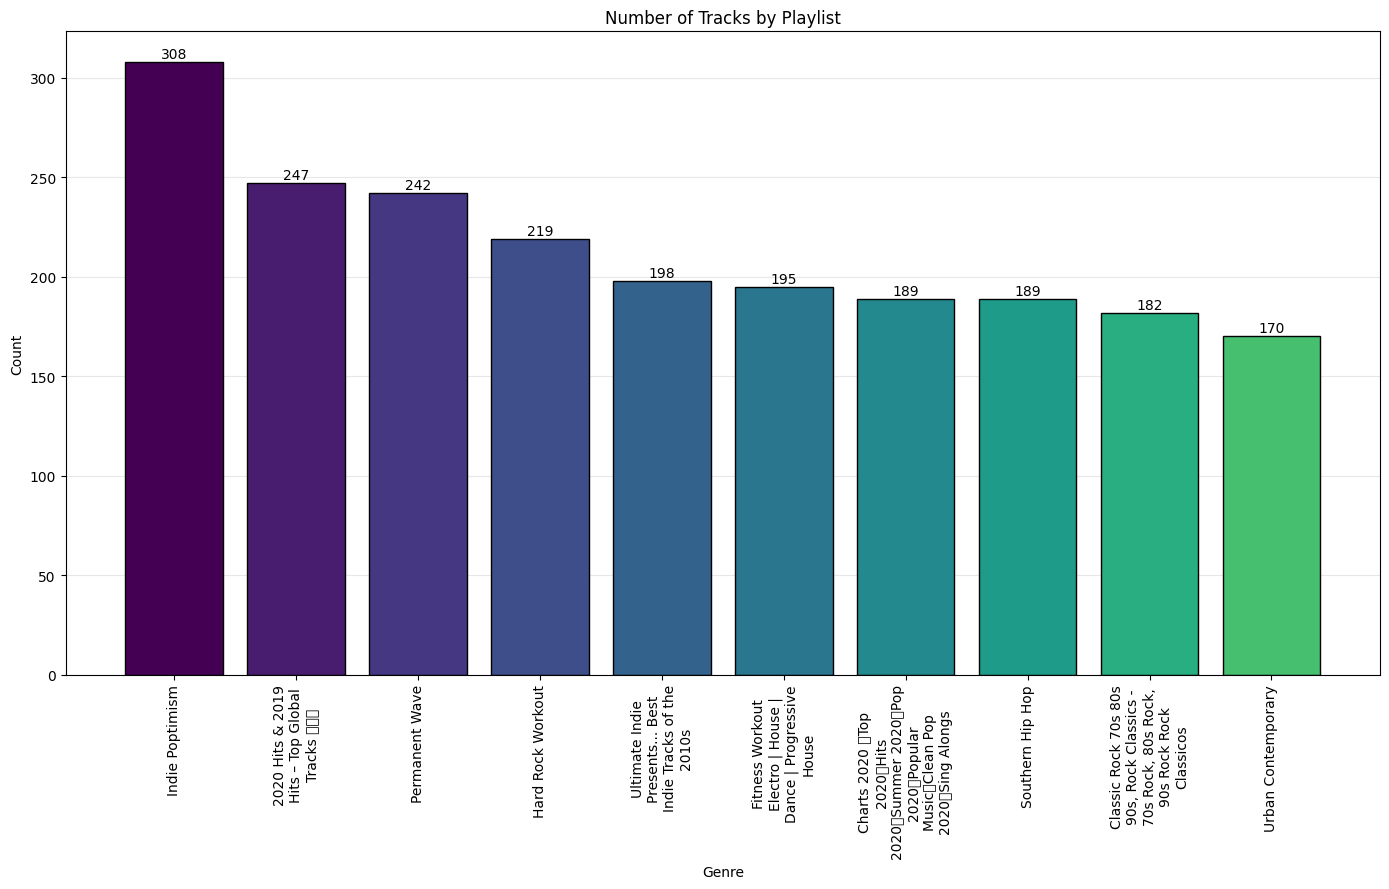

In [9]:
import textwrap
playlist_count=df["playlist_name"].value_counts().head(10)
plt.figure(figsize=(14,9))
colors=plt.cm.viridis(range(0,len(playlist_count)*200,20))
bars=plt.bar(x=playlist_count.index,height=playlist_count.values,color=colors,zorder=2,edgecolor="k")
for bar in bars:
    height=bar.get_height()
    plt.text(
    bar.get_x() + bar.get_width() / 2,  # x-position (center of the bar)
    height + 0.5,                       # y-position (slightly above the bar)
    f"{int(height)}",                   # label text
    ha="center", va="bottom", fontsize=10
    )
plt.grid(True,axis="y",zorder=0,alpha=.3)
plt.title("Number of Tracks by Playlist")
plt.ylabel("Count")
plt.xlabel("Genre")
wrapped_labels = [textwrap.fill(label, width=20) for label in playlist_count.index]
plt.xticks(range(len(wrapped_labels)), wrapped_labels, rotation=90, ha="center")
plt.tight_layout()
plt.show()

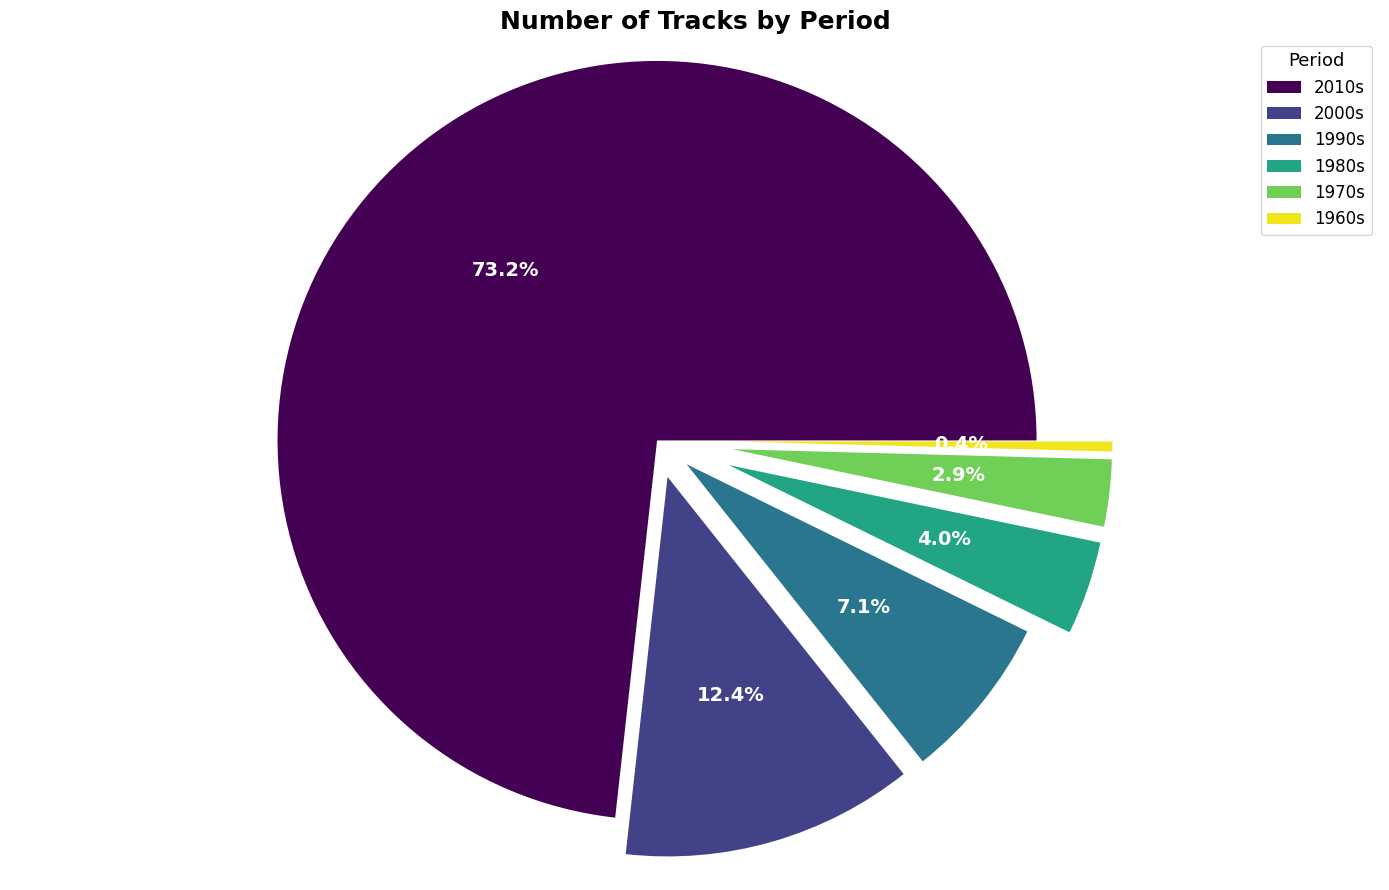

In [47]:
period_count = df["period"].value_counts().head(6)

plt.figure(figsize=(14, 9))
colors = plt.cm.viridis(range(0, len(period_count) * 200, 50))

# Create the pie chart
plt.pie(
    x=period_count.values,
    labels=None,  # remove labels from slices
    colors=colors,
    explode=[0] + [0.1]*2 + [0.2]*3,
    autopct=lambda pct: f"{pct:.1f}%",  # format percentages
    textprops={'color': 'white', 'fontsize': 14, 'weight': 'bold'}  # white + bigger font
)

plt.title("Number of Tracks by Period", fontsize=18, fontweight='bold')
plt.legend(
    labels=period_count.index,
    title="Period",
    loc="best",
    fontsize=12,
    title_fontsize=13
)

plt.axis("equal")
plt.tight_layout()
plt.show()


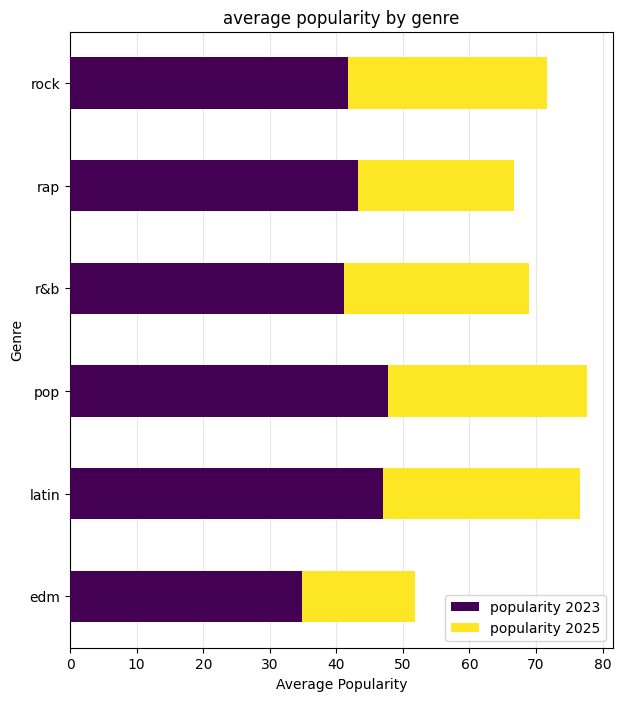

In [48]:
genre_pop=df.groupby("playlist_genre")[["popularity_2023","popularity_2025"]].mean()
fig,ax=plt.subplots(figsize=(7,8))
barse=genre_pop.plot(kind="barh",stacked=True,colormap="viridis",ax=ax,zorder=3)
plt.title("average popularity by genre")
plt.ylabel("Genre")
plt.xlabel("Average Popularity")
plt.legend(["popularity 2023","popularity 2025"])
plt.grid(axis="x",visible=True,alpha=.3)
plt.show()

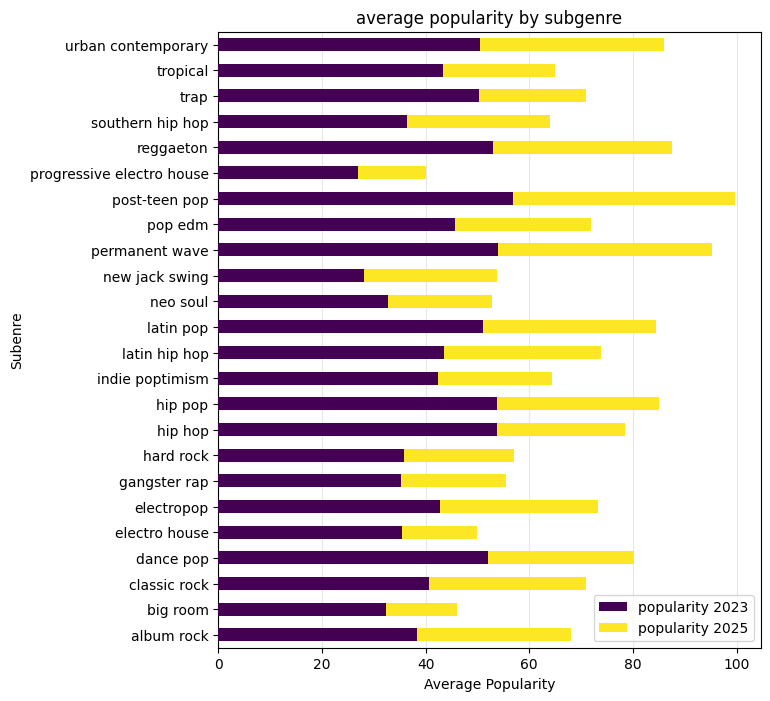

In [49]:
subgenre_pop=df.groupby("playlist_subgenre")[["popularity_2023","popularity_2025"]].mean()
fig,ax=plt.subplots(figsize=(7,8))
barse=subgenre_pop.plot(kind="barh",stacked=True,colormap="viridis",ax=ax,zorder=3)
plt.title("average popularity by subgenre")
plt.ylabel("Subenre")
plt.xlabel("Average Popularity")
plt.legend(["popularity 2023","popularity 2025"])
plt.grid(axis="x",visible=True,alpha=.3)
plt.show()

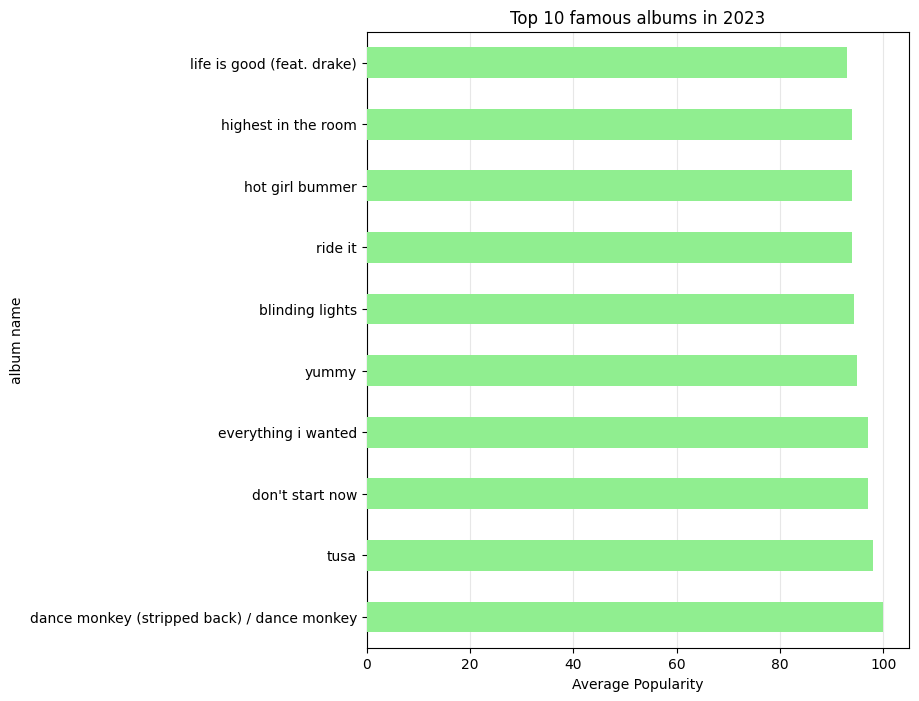

In [50]:
album_pop_2023=df.groupby("track_album_name")["popularity_2023"].mean().sort_values(ascending=False).head(10)
fig,ax=plt.subplots(figsize=(7,8))
barse=album_pop_2023.plot(kind="barh",color="lightgreen",ax=ax,zorder=3)
plt.title("Top 10 famous albums in 2023")
plt.ylabel("album name")
plt.xlabel("Average Popularity")
plt.grid(axis="x",visible=True,alpha=.3)
plt.show()

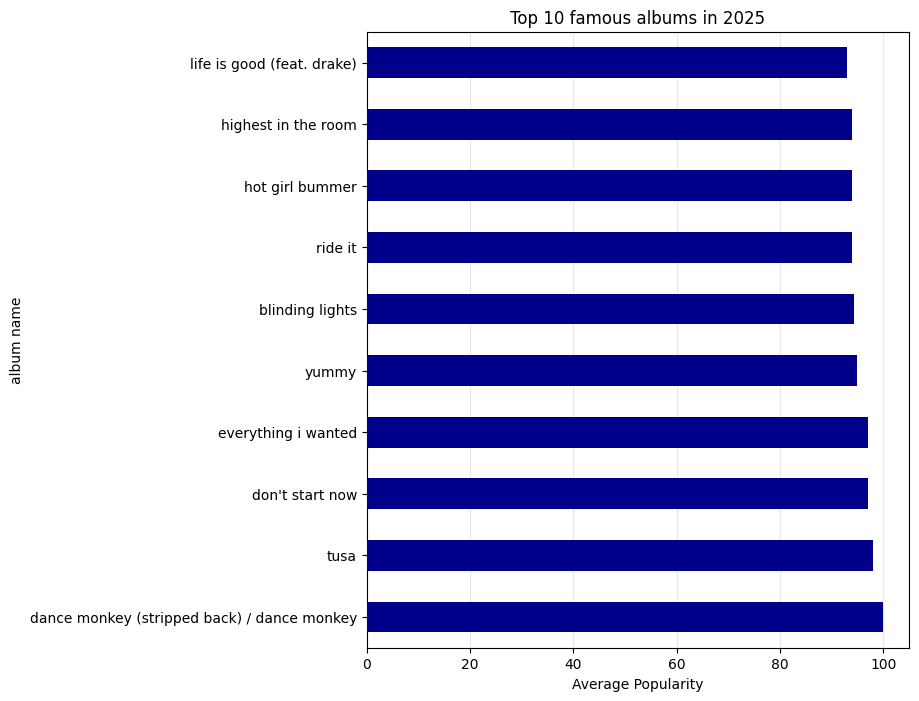

In [51]:
album_pop_2025=df.groupby("track_album_name")["popularity_2023"].mean().sort_values(ascending=False).head(10)
fig,ax=plt.subplots(figsize=(7,8))
barse=album_pop_2025.plot(kind="barh",color="darkblue",ax=ax,zorder=3)
plt.title("Top 10 famous albums in 2025")
plt.ylabel("album name")
plt.xlabel("Average Popularity")
plt.grid(axis="x",visible=True,alpha=.3)
plt.show()

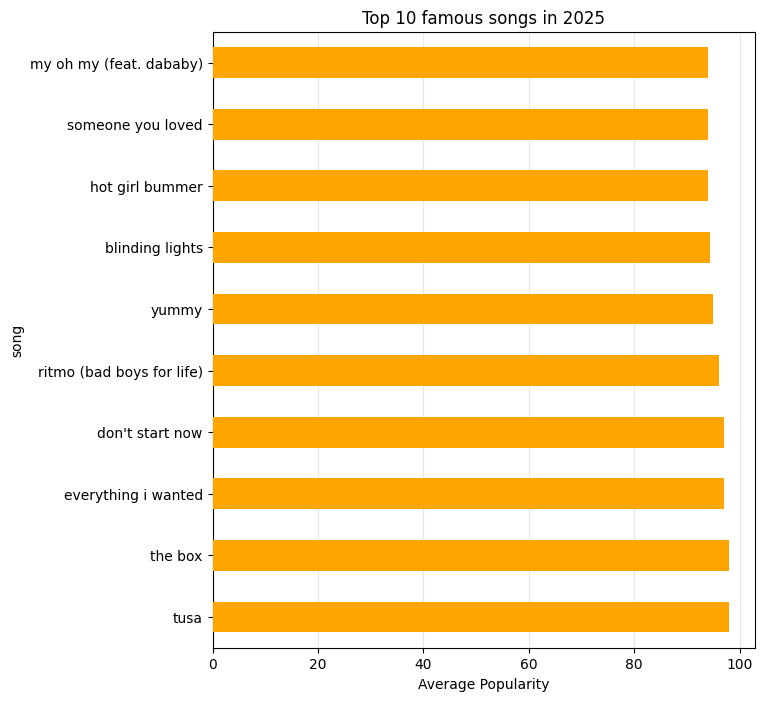

In [10]:
top_songs_2023=df.groupby("track_name")["popularity_2023"].mean().sort_values(ascending=False).head(10)
fig,ax=plt.subplots(figsize=(7,8))
barse=top_songs_2023.plot(kind="barh",color="orange",ax=ax,zorder=3)
plt.title("Top 10 famous songs in 2025")
plt.ylabel("song")
plt.xlabel("Average Popularity")
plt.grid(axis="x",visible=True,alpha=.3)
plt.show()

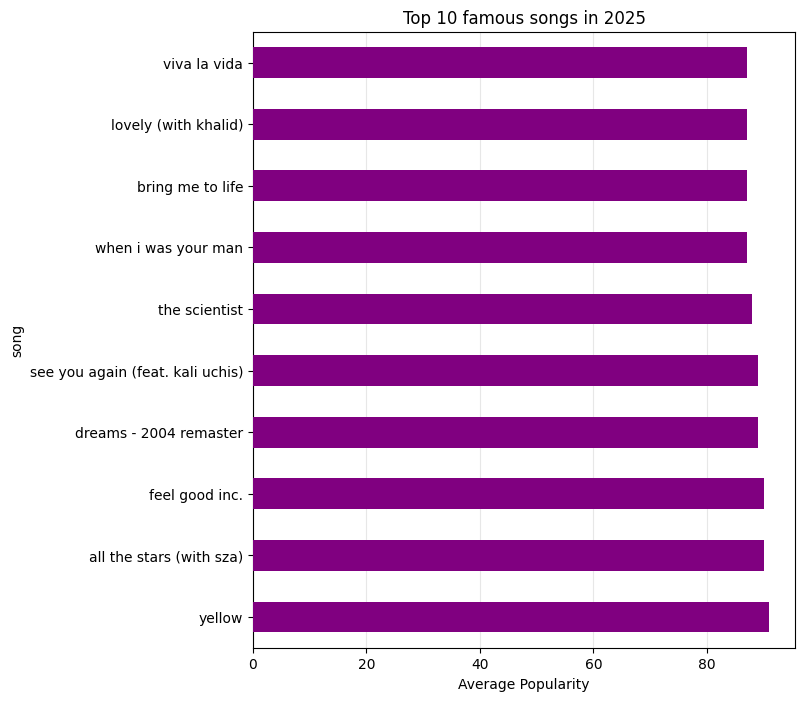

In [11]:
top_songs_2025=df.groupby("track_name")["popularity_2025"].mean().sort_values(ascending=False).head(10)
fig,ax=plt.subplots(figsize=(7,8))
barse=top_songs_2025.plot(kind="barh",color="purple",ax=ax,zorder=3)
plt.title("Top 10 famous songs in 2025")
plt.ylabel("song")
plt.xlabel("Average Popularity")
plt.grid(axis="x",visible=True,alpha=.3)
plt.show()

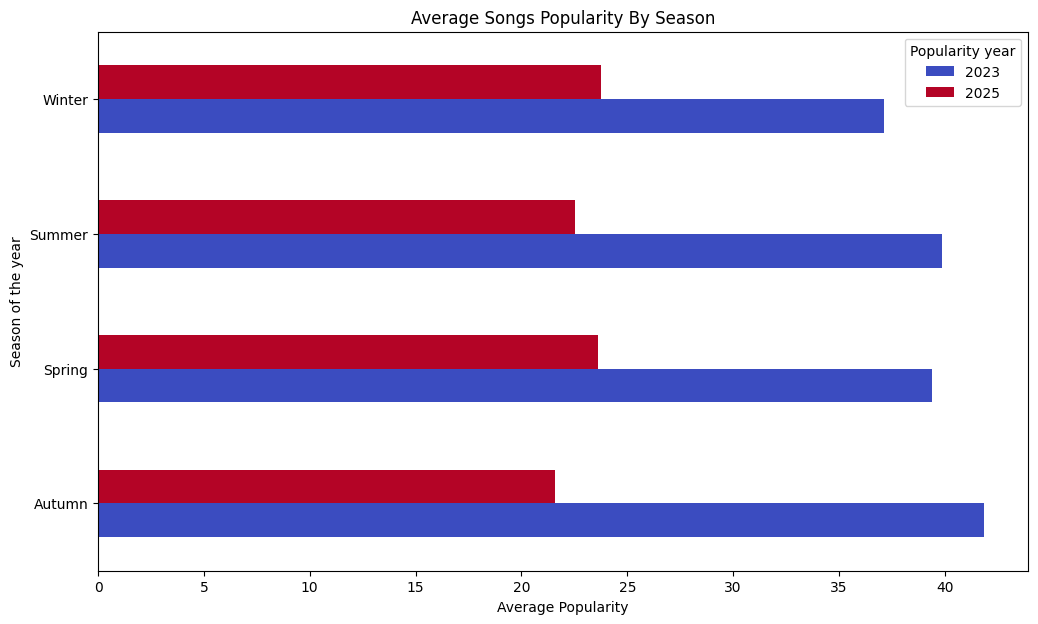

In [12]:
seasonal_popularity=df_grouped.groupby("season")[["popularity_2023","popularity_2025"]].mean()
fig=plt.figure(figsize=(12,7))
ax1=fig.add_subplot()
seasonal_popularity.plot(kind="barh",ax=ax1,colormap="coolwarm")
plt.xlabel("Average Popularity")
plt.ylabel("Season of the year")
plt.title("Average Songs Popularity By Season")
plt.legend(["2023","2025"],title="Popularity year")
plt.show()

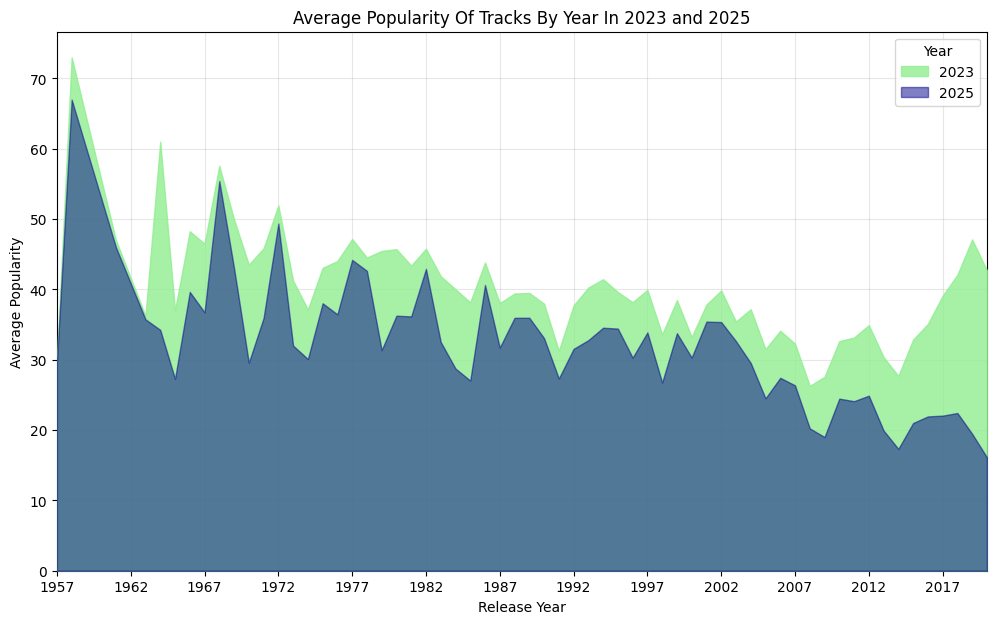

In [55]:
pop_trend_23=df_grouped.groupby("year")["popularity_2023"].mean()
pop_trend_25=df_grouped.groupby("year")["popularity_2025"].mean()
min,max=pop_trend_23.index.min(),pop_trend_23.index.max()
plt.figure(figsize=(12,7))
plt.fill_between(pop_trend_23.index,pop_trend_23.values,color="lightgreen",label="2023",alpha=.8,zorder=3)
plt.fill_between(pop_trend_25.index,pop_trend_25.values,color="darkblue",label="2025",alpha=.5,zorder=3)
plt.title("Average Popularity Of Tracks By Year In 2023 and 2025")
plt.xlabel("Release Year")
plt.ylabel("Average Popularity")
plt.xlim(min,max)
plt.ylim(0)
plt.xticks(np.arange(min,max+1,5))
plt.legend(title="Year")
plt.grid(alpha=.3,zorder=0)
plt.show()

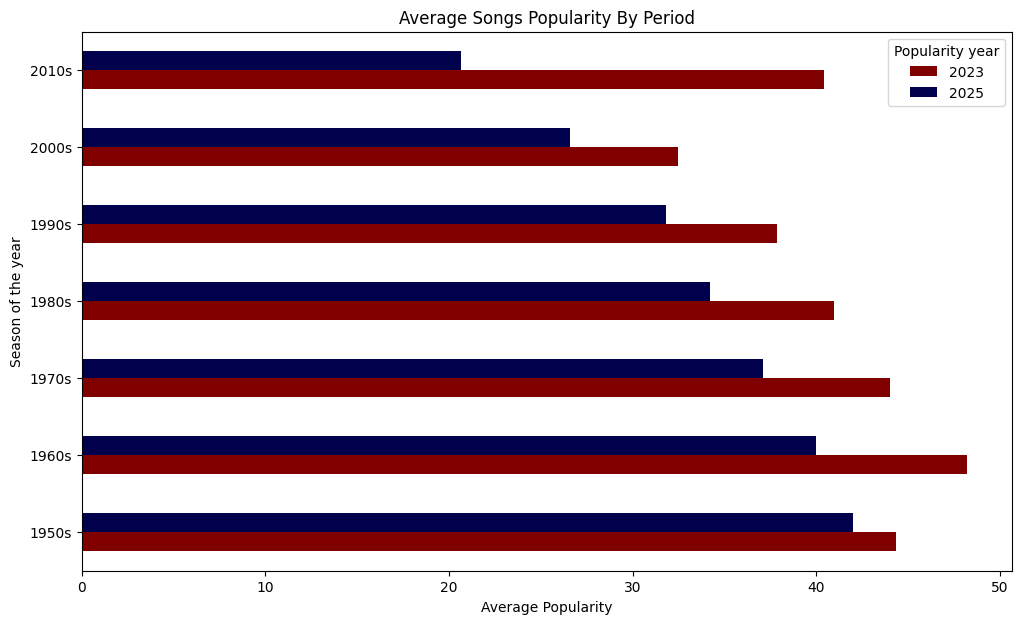

In [56]:
seasonal_popularity=df_grouped.groupby("period")[["popularity_2023","popularity_2025"]].mean()
fig=plt.figure(figsize=(12,7))
ax1=fig.add_subplot()
seasonal_popularity.plot(kind="barh",ax=ax1,colormap="seismic_r")
plt.xlabel("Average Popularity")
plt.ylabel("Season of the year")
plt.title("Average Songs Popularity By Period")
plt.legend(["2023","2025"],title="Popularity year")
plt.show()

In [57]:
df

,track_id,track_name,track_artist,popularity_2023,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,instrumentalness,liveness,valence,tempo,duration_ms,popularity_2025,season,year,period,popularity_categorized
0,6ZMda6mscE8eRkuwlw8yFB,bedsitter,soft cell,18,1xza4j8vMQdGqqQdHa30lI,non stop erotic cabaret (deluxe edition),1981-12-15,"Maxi Pop GOLD (New Wave, Electropop, Synth Po...",2nRWtTI9a2LWjJ9Wy3JZs5,pop,...,0.005380,0.0747,0.610,145.271,215333,12,Autumn,1981,1980s,hardly recognizable
1,4GDmAT5ZZyHdBo32UYDIvM,tainted love,soft cell,53,1xza4j8vMQdGqqQdHa30lI,non stop erotic cabaret (deluxe edition),1981-12-15,Classic Rock Radio,4lIywN6kXl9KPm3OQ8u8G7,rock,...,0.000000,0.2920,0.651,144.543,153880,44,Autumn,1981,1980s,famous
2,4bnNwCbIo9vxlIpu88KV0K,der mussolini - 1998 - remaster,daf,2,2nQmZO698ZhHOkxUaCZPJS,alles ist gut,1981-03-15,Gothic / Industrial / Mittelalter / EBM / Futu...,53CmFroG6MWR5reOOXJX6B,pop,...,0.494000,0.1160,0.867,156.308,235107,0,Winter,1981,1980s,hardly recognizable
3,6KrMDGTp9CtkMLKyftDUTD,wavelength - remastered,van morrison,44,47nhRTYeYBKV5mEfXLV4fb,wavelength,1978-09-15,Classic Rock Retrogamer,6gUFdcGzKAHyDXY9TKC6cP,rock,...,0.001150,0.4630,0.522,142.829,346987,22,Summer,1978,1970s,famous
4,3JXOMZdeJ7uMR7UfC3BN5T,top of the bill - live,scorpions,2,3fWEWigB3tgsGAUN4kNIKf,tokyo tapes (50th anniversary deluxe edition),1978-08-15,This Is Scorpions,37i9dQZF1DWViGKI2U5P2K,rock,...,0.675000,0.9130,0.232,142.665,407333,0,Summer,1978,1970s,hardly recognizable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32757,6JWlRd8ZFnXhCzg0mi3N5V,tin man,america,38,64sDz3NRE1xYuaIZWAyu4N,america's greatest hits - history,1972-01-01,70's Classic Rock,76lrxCrKrGDkDDf3SVPnl3,rock,...,0.013300,0.0836,0.655,172.020,209867,44,NaN,1972,1970s,famous
32758,4wumYSGWMGz0EZazVy9sRd,ventura highway,america,39,64sDz3NRE1xYuaIZWAyu4N,america's greatest hits - history,1972-01-01,70's Classic Rock,76lrxCrKrGDkDDf3SVPnl3,rock,...,0.000200,0.1220,0.838,130.707,211680,46,NaN,1972,1970s,famous
32759,0Osbam159ngkQww6isBBQJ,a horse with no name,america,50,64sDz3NRE1xYuaIZWAyu4N,america's greatest hits - history,1972-01-01,70's Classic Rock,76lrxCrKrGDkDDf3SVPnl3,rock,...,0.015500,0.1550,0.831,123.179,252240,48,NaN,1972,1970s,famous
32760,2DnJjbjNTV9Nd5NOa1KGba,you're so vain,carly simon,75,79x0PRGIZv33znrCkPkCZ5,no secrets,1972-01-01,70's Classic Rock,76lrxCrKrGDkDDf3SVPnl3,rock,...,0.000007,0.0784,0.647,106.186,258411,77,NaN,1972,1970s,hit


In [13]:
import plotly.express as px

# --- Group by year and calculate average popularity ---
yearly_genre_popularity = df.groupby(["year","playlist_genre"]).agg(
    avg_popularity=("popularity_2025", "mean")
).reset_index()

# Drop any rows with NaN year (if release_date was missing)
yearly_genre_popularity = yearly_genre_popularity.dropna(subset=["year"])

# --- Line plot: Avg popularity by year ---
fig = px.line(
    yearly_genre_popularity,
    x="year",
    y="avg_popularity",
    color="playlist_genre",
    markers=True,
    labels={"year": "Album/Track Release Year", "avg_popularity": "Average Popularity"},
    template="plotly_dark",
    title="Average Popularity of Songs Genres by Year",
    width=1000
)

fig.update_traces(
    textposition="top center",
    textfont=dict(size=11, color="white")
)

fig.update_layout(
    plot_bgcolor="#121212",
    paper_bgcolor="#121212",
    xaxis=dict(dtick=5),  # show every year on x-axis
)

fig.show()

<h4>Top Arabic Songs in 2025 & Eminem Songs Performance<h4>

In [126]:
import plotly.express as px
import pandas as pd
import ast

# --- Load & prepare data ---
df_arabic = pd.read_json(r"playlist_songs_and_ids.json").transpose()
df_arabic.index.name = "track_name"
df_arabic.reset_index(inplace=True)
df_arabic["popularity_score"] = df_arabic["popularity_score"].astype(int)

# --- Safely parse artist names ---
def safe_eval(x):
    if isinstance(x, str):
        try:
            lst = ast.literal_eval(x)
            if isinstance(lst, list):
                return ", ".join(lst)
        except:
            pass
    return x

df_arabic["artist_name"] = df_arabic["artist_name"].apply(safe_eval)

# --- Get top 20 tracks by popularity ---
pop_arabic = df_arabic.sort_values("popularity_score", ascending=False).head(20)

# --- Spotify-style bar chart ---
fig = px.bar(
    pop_arabic,
    y="track_name",
    x="popularity_score",
    text="artist_name",
    color="popularity_score",
    color_continuous_scale="viridis",
)

# --- Layout & style tweaks ---
fig.update_traces(
    textposition="inside",
    insidetextanchor="end",
    textfont=dict(size=12, color="white"),
)

fig.update_layout(
    template="plotly_dark",
    title=dict(
        text="Top 20 Most Popular Tracks in Arabic Countries on Spotify",
        font=dict(size=22, color="white"),
        x=0.5,
    ),
    xaxis_title="Popularity Score",
    yaxis_title="",
    yaxis=dict(
        tickfont=dict(size=13, color="white"),
        automargin=True,
        ticklabelposition="outside right",
    ),
    margin=dict(l=180, r=40, t=70, b=50),
    coloraxis_showscale=False,
    plot_bgcolor="#121212",
    paper_bgcolor="#121212",
)

fig.show()

In [127]:
df_arabic.to_csv(r"arabic_playlist.csv")

In [121]:
import pandas as pd
import json

with open(r"NF_tracks.json",encoding="utf-8") as f:
    data=json.load(f)

# Flatten the nested structure
all_songs = []

for album_name, songs in data.items():
    for song_name, song_attrs in songs.items():
        all_songs.append(song_attrs)

df_NF = pd.DataFrame(all_songs)

columns_order = ["name", "album_name", "release_date", "popularity", "duration_ms", "explicit",]
df_NF = df_NF[columns_order]

print("Duplicates Count:",len(df_NF[df_NF[["name","album_name"]].duplicated()]))
print("Null Entries Count:\n",df_NF.isna().sum())

Duplicates Count: 0
Null Entries Count:
 name            0
album_name      0
release_date    0
popularity      0
duration_ms     0
explicit        0
dtype: int64


In [123]:
df_NF.to_csv(r"NF_songs_data.csv")

In [16]:
import pandas as pd
import json

with open(r"eminem_tracks.json",encoding="utf-8") as f:
    data=json.load(f)

# Flatten the nested structure
all_songs = []

for album_name, songs in data.items():
    for song_name, song_attrs in songs.items():
        all_songs.append(song_attrs)

df_eminem = pd.DataFrame(all_songs)

columns_order = ["name", "album_name", "release_date", "popularity", "duration_ms", "explicit",]
df_eminem = df_eminem[columns_order]

print("Duplicates Count:",len(df_eminem[df_eminem[["name","album_name"]].duplicated()]))
print("Null Entries Count:\n",df_eminem.isna().sum())

Duplicates Count: 0
Null Entries Count:
 name            0
album_name      0
release_date    0
popularity      0
duration_ms     0
explicit        0
dtype: int64


In [17]:
#check if we should remove songs with same names as albums or not
names_as_albums=df_eminem[df_eminem["name"]==df_eminem["album_name"]]["name"].values.tolist()
df_eminem_mod=df_eminem[df_eminem["name"]!=df_eminem["album_name"]].copy()

i=0
while i<len(names_as_albums):
   if not(names_as_albums[i] in df_eminem_mod["name"].unique().tolist()):
      print(f"Track name '{names_as_albums[i]}' is missing")
   i+=1

Track name 'Kamikaze' is missing
Track name 'Animals (Pt. I) [with Eminem]' is missing
Track name 'Gunz N Smoke (feat. 50 Cent & Eminem)' is missing
Track name 'Somebody Save Me (feat. Jelly Roll)' is missing
Track name 'Lace It (with Eminem & benny blanco)' is missing
Track name 'Realest (with Eminem)' is missing
Track name 'Gospel (with Eminem)' is missing
Track name 'The Adventures of Moon Man & Slim Shady (with Eminem)' is missing
Track name 'Remember The Name (feat. Eminem & 50 Cent)' is missing
Track name 'Homicide' is missing
Track name 'Killshot' is missing
Track name 'Campaign Speech' is missing
Track name 'Guts Over Fear' is missing
Track name 'When I'm Gone' is missing


In [18]:
df_eminem.to_csv(r"eminem_songs.csv")

hence we should keep these tracks with repeated names

In [19]:
import plotly.express as px
import ast 
df_eminem=pd.read_csv(r"eminem_songs.csv")

# --- Get top 20 tracks by popularity ---
pop_em = df_eminem.sort_values("popularity", ascending=False).head(25).drop_duplicates("name",keep="last").head(20)

# --- Spotify-style bar chart ---
fig1 = px.bar(
    pop_em,
    y="name",
    x="popularity",
    text="album_name",
    color="popularity",
    color_continuous_scale="viridis",
    height=700
)

# --- Layout & style tweaks ---
fig1.update_traces(
    textposition="inside",
    insidetextanchor="end",
    textfont=dict(size=12, color="white"),
)

fig1.update_layout(
    template="plotly_dark",
    title=dict(
        text="Top 20 Most Popular Tracks By Eminem In 2025",
        font=dict(size=22, color="white"),
        x=0.5,
    ),
    xaxis_title="Popularity Score",
    yaxis_title="Track Name",
    yaxis=dict(
        tickfont=dict(size=13, color="white"),
        automargin=True,
        ticklabelposition="outside right",
    ),
    margin=dict(l=180, r=40, t=70, b=50),
    coloraxis_showscale=False,
    plot_bgcolor="#121212",
    paper_bgcolor="#121212",
)

fig1.show()

In [20]:
df_eminem

,Unnamed: 0,name,album_name,release_date,popularity,duration_ms,explicit
0,0,Stan,STANS (The Official Soundtrack),2025-08-26,60,404106,True
1,1,Bad Guy,STANS (The Official Soundtrack),2025-08-26,55,434358,True
2,2,Arose,STANS (The Official Soundtrack),2025-08-26,52,274626,True
3,3,Beautiful,STANS (The Official Soundtrack),2025-08-26,54,392826,True
4,4,Not Afraid,STANS (The Official Soundtrack),2025-08-26,52,248133,True
...,...,...,...,...,...,...,...
535,535,Forever,Forever,2009-01-01,68,357920,True
536,536,Shake That - Radio Edit,Shake That (Radio Edit Version),2006-01-17,64,274106,False
537,537,When I'm Gone,When I'm Gone,2005-12-06,62,281120,True
538,538,Business,When I'm Gone,2005-12-06,31,251933,True


In [22]:
# --- Aggregate album-level info ---
album_stats = df_eminem.groupby("album_name").agg(
    song_count=("name", "count"),
    avg_popularity=("popularity", "mean"),
    most_popular_song=("popularity", lambda x: df_eminem.loc[x.idxmax(), "name"],),
    release_date=("release_date","first")
).reset_index()

# Round average popularity for hover clarity
album_stats["avg_popularity_rounded"] = album_stats["avg_popularity"].round(1)
album_stats=album_stats.sort_values("avg_popularity").head(15)
# --- Bubble plot ---
fig = px.scatter(
    album_stats,
    x="release_date",
    y="song_count",
    size="avg_popularity",
    color="avg_popularity",
    hover_data={
        "album_name": True,
        "song_count": True,
        "avg_popularity_rounded": True,
        "most_popular_song": True
    },
    text="album_name",
    size_max=60,
    color_continuous_scale="viridis",
    template="plotly_dark",
    height=900
)

# --- Layout tweaks ---
fig.update_traces(
    textposition="top center",
    textfont=dict(size=11, color="white")
)

fig.update_layout(
    title=dict(
        text="Eminem Albums: Song Count vs Avg Popularity vs Album Release Date",
        font=dict(size=20, color="white"),
        x=0.5
    ),
    xaxis_title="Album Name",
    yaxis_title="Number of Songs",
    xaxis_tickangle=-45,
    plot_bgcolor="#121212",
    paper_bgcolor="#121212",
    coloraxis_showscale=False,
    margin=dict(l=100, r=50, t=80, b=200)
)

fig.show()


In [14]:
# --- Convert release_date to datetime and extract year ---
df_eminem["release_date"] = pd.to_datetime(df_eminem["release_date"], errors="coerce")
df_eminem["release_year"] = df_eminem["release_date"].dt.year

# --- Group by year and calculate average popularity ---
yearly_popularity = df_eminem.groupby("release_year").agg(
    avg_popularity=("popularity", "mean"),
    song_count=("name", "count")
).reset_index()

# Drop any rows with NaN year (if release_date was missing)
yearly_popularity = yearly_popularity.dropna(subset=["release_year"])

# --- Line plot: Avg popularity by year ---
fig = px.line(
    yearly_popularity,
    x="release_year",
    y="avg_popularity",
    markers=True,
    text="song_count",  # optional: show how many songs released
    labels={"release_year": "Year", "avg_popularity": "Average Popularity"},
    template="plotly_dark",
    title="Average Popularity of Eminem's Songs by Year"
)

fig.update_traces(
    textposition="top center",
    textfont=dict(size=11, color="white")
)

fig.update_layout(
    plot_bgcolor="#121212",
    paper_bgcolor="#121212",
    xaxis=dict(dtick=1),  # show every year on x-axis
)

fig.show()


In [15]:
#import package and its set of stopwords
from wordcloud import WordCloud, STOPWORDS
import urllib

print ('Wordcloud imported!')

Wordcloud imported!


In [23]:
names=""
for value,popularity in zip(df_eminem["name"].values.tolist(),df_eminem["popularity"].values.tolist()):
    names+=(" "+value.lower())*popularity
stopwords = set(STOPWORDS)
words_del=["feat","instrumental","eminem"]
for word in words_del:
    stopwords.add(word)
eminem_wc=WordCloud(stopwords=stopwords,background_color='white')
eminem_wc.generate(names)


In [24]:
print(names)

 stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan stan bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy bad guy arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose arose a

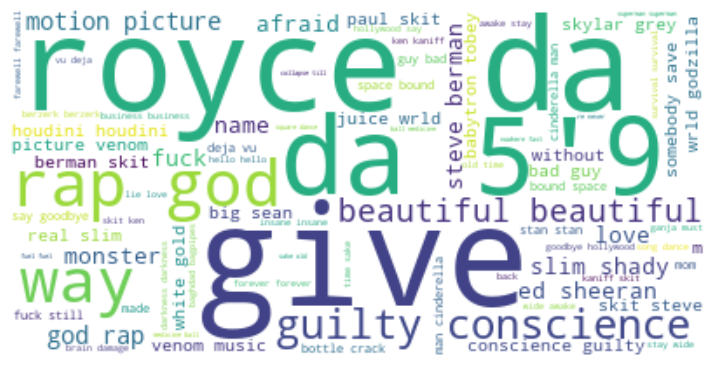

In [25]:
plt.figure(figsize=(9,6))
plt.imshow(eminem_wc,interpolation="bilinear")
plt.axis('off')
plt.show()

In [26]:
import numpy as np
from PIL import Image
import urllib.request

# Direct URL of the image file (not webpage)
eminem_mask_img = "eminem_silouhette2.jpg"

# Load the mask
eminem_mask = np.array(Image.open(eminem_mask_img))

print(eminem_mask.shape)


(1200, 970)


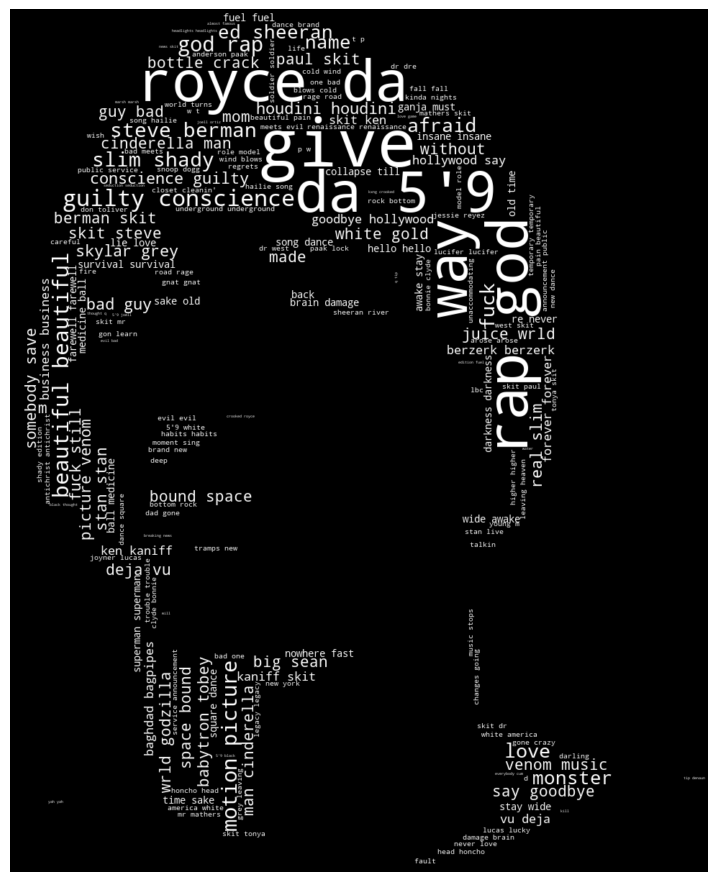

In [34]:
eminem_wc=WordCloud(stopwords=stopwords,
                    mask=eminem_mask,
                    background_color='black',
                    color_func=lambda *args, **kwargs: "white",
                    mode="RGBA"
                )
eminem_wc.generate(names)

plt.figure(figsize=(9, 12))
plt.imshow(eminem_wc, cmap=plt.cm.gray, interpolation='bilinear')
plt.axis('off')
plt.show()

Machine Learning

In [ ]:
# --- Imports ---
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 0: Encode multi-label categorical features ---
df_mod=df_grouped.copy()
mlb_genre = MultiLabelBinarizer()
genres = df_mod["playlist_genre"].str.split("; ")
genre_encoded = mlb_genre.fit_transform(genres)
genre_df = pd.DataFrame(genre_encoded, columns=mlb_genre.classes_)
df_mod = pd.concat([df_mod.drop(columns=["playlist_genre"]), genre_df], axis=1)

mlb_sub = MultiLabelBinarizer()
subgenres = df_mod["playlist_subgenre"].str.split("; ")
subgenre_encoded = mlb_sub.fit_transform(subgenres)
subgenre_df = pd.DataFrame(subgenre_encoded, columns=mlb_sub.classes_)
df_mod = pd.concat([df_mod.drop(columns=["playlist_subgenre"]), subgenre_df], axis=1)

# --- Step 1: Define target and features ---
y = np.log1p(df_mod["popularity_2025"])
X = df_mod.drop(columns=[
    "popularity_2025",
    "popularity_2023",
    "popularity_categorized",
    "track_name",
    "track_id",
    "track_artist",
    "track_album_release_date",
    "period",
    "popularity_norm"
], errors="ignore")
# --- Step 2: Split data ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Step 3: Identify categorical and numeric features ---
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_features = X.select_dtypes(include=['number']).columns.tolist()

# --- Step 4: Handle missing values ---
for col in cat_features:
    X_train[col] = X_train[col].astype(str).fillna("Unknown")
    X_test[col] = X_test[col].astype(str).fillna("Unknown")

for col in num_features:
    X_train[col] = X_train[col].fillna(X_train[col].median())
    X_test[col] = X_test[col].fillna(X_train[col].median())

# --- Step 5: Create CatBoost Pools ---
train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)

# --- Step 6: Define base model ---
base_model = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    iterations=500,              # reduced iterations for speed
    early_stopping_rounds=50,
    verbose=50
)

# --- Step 7: Hyperparameter tuning using RandomizedSearchCV ---
param_dist = {
    'depth': [8, 10, 12],
    'learning_rate': [0.03, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7],
    'iterations': [800, 1200, 1500]
}


random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=6,            # small number of random combos
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train, cat_features=cat_features)

print("✅ Best Params:", random_search.best_params_)
print("📈 Best CV RMSE:", -random_search.best_score_)

# --- Step 8: Train final model with best params ---
best_model = random_search.best_estimator_
best_model.fit(train_pool, eval_set=test_pool, verbose=100, early_stopping_rounds=50)

# --- Step 9: Predict and evaluate ---
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)  # inverse of log1p

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n📊 Regression Results:")
print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ R2 Score: {r2:.4f}")

# Optional: Plot predicted vs actual
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Predicted vs Actual Popularity")
plt.show()

# --- Step 10: Feature importance ---
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.get_feature_importance()
}).sort_values(by="Importance", ascending=False)

print("\n🔥 Top 10 Important Features:")
print(importances.head(10))


Fitting 3 folds for each of 6 candidates, totalling 18 fits


KeyboardInterrupt: 

In [128]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from imblearn.over_sampling import SMOTENC

# --- Prepare dataset ---
df_mod = df_grouped.copy()
threshold = 15  # can adjust or use quantiles
df_mod['popularity_class'] = (df_mod['popularity_2025'] >= threshold).astype(int)

y_class = df_mod['popularity_class']
X_features = df_mod.drop(columns=[
    'popularity_2025',
    'popularity_class',
    "popularity_2023",
    "popularity_categorized",
    "track_album_release_date",
    "track_name",
])

# Identify categorical columns
cat_features = X_features.select_dtypes(include=['object', 'category']).columns.tolist()

# Ensure all categorical are strings
for col in cat_features:
    X_features[col] = X_features[col].astype(str).fillna("Unknown")

# Train-test split
X_train, X_test, y_train_class, y_test_class = train_test_split(
    X_features, y_class, test_size=0.1, random_state=42
)

# --- Step 0: Handle imbalance with SMOTENC ---
cat_indices = [X_train.columns.get_loc(c) for c in cat_features]  # categorical column indices
smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)
X_resampled, y_resampled_class = smote_nc.fit_resample(X_train, y_train_class)

# --- Step 1: Train classifier for segments ---
cat_model_class = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    iterations=500,
    depth=8,
    learning_rate=0.05,
    verbose=100,
)

cat_model_class.fit(
    X_resampled, y_resampled_class,
    eval_set=(X_test, y_test_class),
    cat_features=cat_features
)

# --- Step 2: Prepare regression targets ---
y_train_reg = df_mod.loc[X_train.index, 'popularity_2025']
y_test_reg = df_mod.loc[X_test.index, 'popularity_2025']

# Split train by predicted segments
train_prob = cat_model_class.predict_proba(X_train)[:,1]  # probability of high popularity
train_segments = (train_prob >= 0.5).astype(int)

X_train_low = X_train[train_segments == 0]
y_train_low = y_train_reg[X_train_low.index]

X_train_high = X_train[train_segments == 1]
y_train_high = y_train_reg[X_train_high.index]

# --- Step 3: Train separate regressors ---
categorical_features_low = X_train_low.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features_high = X_train_high.select_dtypes(include=['object', 'category']).columns.tolist()

model_low = CatBoostRegressor(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    loss_function='RMSE',
    verbose=100,
)
model_high = CatBoostRegressor(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    loss_function='RMSE',
    verbose=100,
)

model_low.fit(X_train_low, y_train_low, cat_features=categorical_features_low)
model_high.fit(X_train_high, y_train_high, cat_features=categorical_features_high)

# --- Step 4: Predict on test set using probabilities ---
test_prob = cat_model_class.predict_proba(X_test)[:,1]

pred_low = model_low.predict(X_test)
pred_high = model_high.predict(X_test)

# Blend predictions by probability
test_predictions = pred_low * (1 - test_prob) + pred_high * test_prob

# --- Step 5: Evaluate ---
rmse = root_mean_squared_error(y_test_reg, test_predictions)
r2 = r2_score(y_test_reg, test_predictions)

print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ R2 Score: {r2:.4f}")





0:	test: 0.7669996	best: 0.7669996 (0)	total: 237ms	remaining: 1m 58s
100:	test: 0.8679033	best: 0.8679033 (100)	total: 9.7s	remaining: 38.3s
200:	test: 0.8727309	best: 0.8727309 (200)	total: 18.9s	remaining: 28.2s
300:	test: 0.8734895	best: 0.8736650 (286)	total: 28.8s	remaining: 19s
400:	test: 0.8739596	best: 0.8740191 (356)	total: 38.7s	remaining: 9.55s
499:	test: 0.8740267	best: 0.8745224 (455)	total: 49.6s	remaining: 0us

bestTest = 0.8745223688
bestIteration = 455

Shrink model to first 456 iterations.
0:	learn: 4.9453451	total: 56.6ms	remaining: 28.2s
100:	learn: 4.4916933	total: 6.18s	remaining: 24.4s
200:	learn: 4.3027977	total: 13s	remaining: 19.3s
300:	learn: 4.1581561	total: 19.2s	remaining: 12.7s
400:	learn: 4.0060626	total: 26.2s	remaining: 6.46s
499:	learn: 3.8639433	total: 34s	remaining: 0us
0:	learn: 17.5775279	total: 75ms	remaining: 37.4s
100:	learn: 12.5854010	total: 7.66s	remaining: 30.3s
200:	learn: 11.9084463	total: 14.8s	remaining: 22.1s
300:	learn: 11.3959220	to

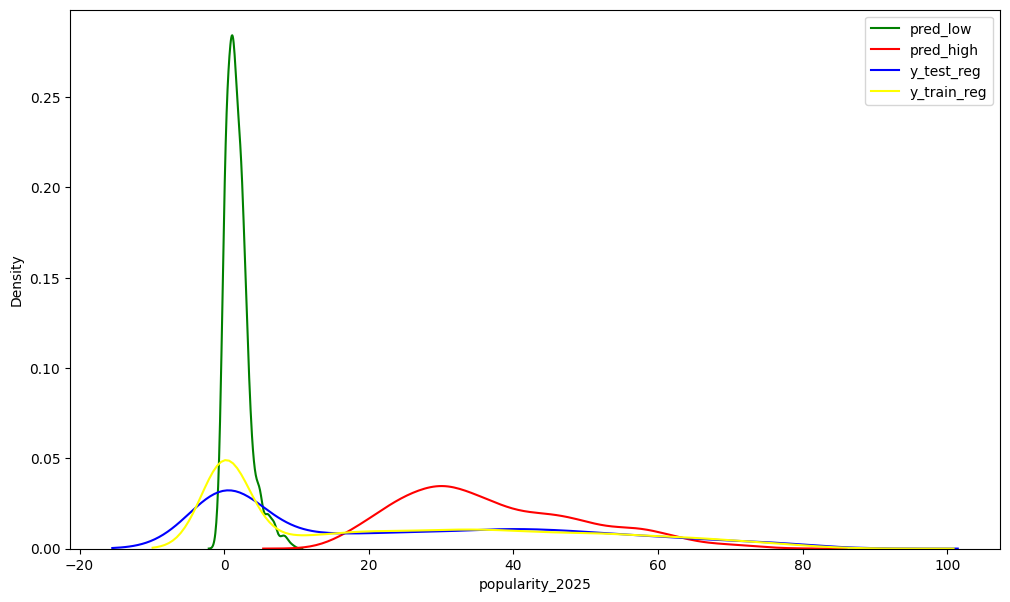

In [129]:
plt.figure(figsize=(12,7))
sns.kdeplot(pred_low,color="green",label="pred_low")
sns.kdeplot(pred_high,color="red",label="pred_high")
sns.kdeplot(y_test_reg,color="blue",label="y_test_reg")
sns.kdeplot(y_train_reg,color="yellow",label="y_train_reg")
plt.legend()
plt.show()


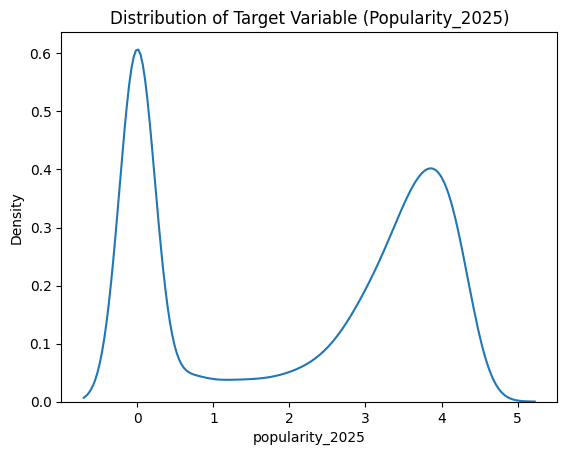

In [131]:
sns.kdeplot(np.log1p(y))
plt.title("Distribution of Target Variable (Popularity_2025)")
plt.show()

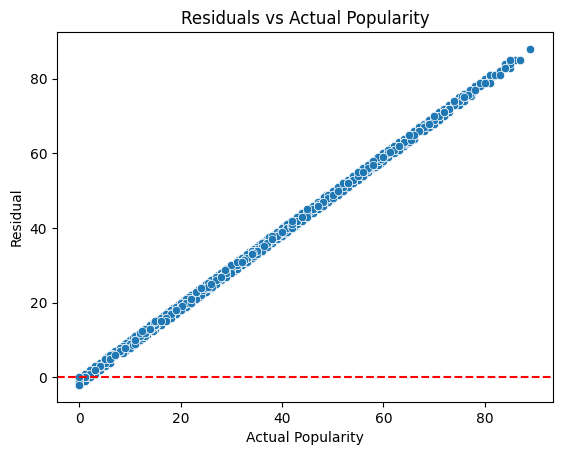

In [134]:
#y_test vs residuals
residuals = y_test - y_pred
sns.scatterplot(x=y_test, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Actual Popularity")
plt.ylabel("Residual")
plt.title("Residuals vs Actual Popularity")
plt.show()

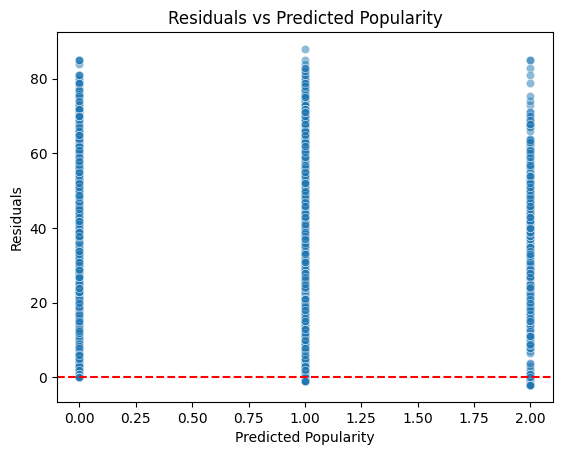

In [135]:
#y_pred vs residuals
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Popularity")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Popularity")
plt.show()


Regression

In [ ]:
# --- Imports ---
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 0: Encode multi-label categorical features ---
df_mod=df_grouped.copy()
mlb_genre = MultiLabelBinarizer()
genres = df_mod["playlist_genre"].str.split("; ")
genre_encoded = mlb_genre.fit_transform(genres)
genre_df = pd.DataFrame(genre_encoded, columns=mlb_genre.classes_)
df_mod = pd.concat([df_mod.drop(columns=["playlist_genre"]), genre_df], axis=1)

mlb_sub = MultiLabelBinarizer()
subgenres = df_mod["playlist_subgenre"].str.split("; ")
subgenre_encoded = mlb_sub.fit_transform(subgenres)
subgenre_df = pd.DataFrame(subgenre_encoded, columns=mlb_sub.classes_)
df_mod = pd.concat([df_mod.drop(columns=["playlist_subgenre"]), subgenre_df], axis=1)

# --- Step 1: Define target and features ---
y = df_mod["popularity_2025"]
y=np.log1p(y)
X = df_mod.drop(columns=[
    "popularity_2025",
    "popularity_2023",
    "popularity_categorized",
    "track_name",
    "track_id",
    "track_artist",
    "popularity_norm",
    "year",
    "rap",
    "r&b",
    "latin",
    "pop",
    "edm",
    "rock"
], errors="ignore")

# --- Step 2: Split data ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Step 3: Identify categorical and numeric features ---
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_features = X.select_dtypes(include=['number']).columns.tolist()

# --- Step 4: Handle missing values ---
for col in cat_features:
    X_train[col] = X_train[col].astype(str).fillna("Unknown")
    X_test[col] = X_test[col].astype(str).fillna("Unknown")

for col in num_features:
    X_train[col] = X_train[col].fillna(X_train[col].median())
    X_test[col] = X_test[col].fillna(X_train[col].median())




In [157]:
#check for multicollinearity
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


# Only numeric features
X_numeric = X.select_dtypes(include=[np.number])

# Add constant for statsmodels
X_numeric_const = add_constant(X_numeric)

vif_data = pd.DataFrame()
vif_data["feature"] = X_numeric_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric_const.values, i)
                   for i in range(X_numeric_const.shape[1])]
vif_data.sort_values(by="VIF",ascending=False,inplace=True)

print(vif_data)

                      feature         VIF
0                       const  186.175748
3                      energy    2.988978
5                    loudness    2.403957
14                release_age    1.872567
2                danceability    1.578529
8                acousticness    1.564257
11                    valence    1.513300
7                 speechiness    1.356656
9            instrumentalness    1.322333
13             artist_avg_pop    1.237274
1                 duration_ms    1.234265
16                 album rock    1.233987
24                    hip hop    1.192570
22               gangster rap    1.191977
34  progressive electro house    1.191383
18               classic rock    1.190159
23                  hard rock    1.166937
15          artist_song_count    1.166474
36           southern hip hop    1.165787
30             new jack swing    1.140564
20              electro house    1.135765
35                  reggaeton    1.133230
29                   neo soul    1

In [158]:
# --- Step 5: Create CatBoost Pools ---
train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)

# --- Step 6: Define base model ---
base_model = CatBoostRegressor(
    iterations=1000,
    depth=8,
    learning_rate=0.0001,
    loss_function='RMSE',
    random_seed=4,
    border_count=254,        # finer splits
    feature_border_type='GreedyLogSum',
    grow_policy='Lossguide', # deeper per-leaf growth
)

In [159]:
# --- Step 7: Hyperparameter tuning using RandomizedSearchCV ---
param_dist = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.1, 0.05, 0.01],
    'l2_leaf_reg': [1, 3, 5, 10]
}


random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=6,            # small number of random combos
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train, cat_features=cat_features)

print("✅ Best Params:", random_search.best_params_)
print("📈 Best CV RMSE:", -random_search.best_score_)


Fitting 3 folds for each of 6 candidates, totalling 18 fits
0:	learn: 24.0080274	total: 179ms	remaining: 2m 58s
1:	learn: 23.9281802	total: 358ms	remaining: 2m 58s
2:	learn: 23.8485620	total: 521ms	remaining: 2m 53s
3:	learn: 23.7685915	total: 691ms	remaining: 2m 52s
4:	learn: 23.6905758	total: 876ms	remaining: 2m 54s
5:	learn: 23.6085951	total: 1.05s	remaining: 2m 54s
6:	learn: 23.5348667	total: 1.24s	remaining: 2m 56s
7:	learn: 23.4605670	total: 1.43s	remaining: 2m 56s
8:	learn: 23.3847284	total: 1.61s	remaining: 2m 57s
9:	learn: 23.3111824	total: 1.79s	remaining: 2m 57s
10:	learn: 23.2395232	total: 2.02s	remaining: 3m 1s
11:	learn: 23.1686812	total: 2.19s	remaining: 3m
12:	learn: 23.0975716	total: 2.37s	remaining: 2m 59s
13:	learn: 23.0262899	total: 2.54s	remaining: 2m 59s
14:	learn: 22.9565379	total: 2.72s	remaining: 2m 58s
15:	learn: 22.8891378	total: 2.89s	remaining: 2m 58s
16:	learn: 22.8209111	total: 3.07s	remaining: 2m 57s
17:	learn: 22.7554338	total: 3.24s	remaining: 2m 56s
1

0:	learn: 24.0080274	test: 24.0194118	best: 24.0194118 (0)	total: 250ms	remaining: 4m 9s
100:	learn: 19.5397613	test: 19.4222068	best: 19.4222068 (100)	total: 21.6s	remaining: 3m 12s
200:	learn: 18.3290532	test: 18.2669177	best: 18.2669177 (200)	total: 39.3s	remaining: 2m 36s
300:	learn: 17.8586634	test: 17.8953643	best: 17.8953643 (300)	total: 1m 1s	remaining: 2m 22s
400:	learn: 17.6087362	test: 17.7363523	best: 17.7363523 (400)	total: 1m 23s	remaining: 2m 4s
500:	learn: 17.4505831	test: 17.6642066	best: 17.6642066 (500)	total: 1m 45s	remaining: 1m 44s
600:	learn: 17.3163435	test: 17.6107159	best: 17.6107159 (600)	total: 2m 8s	remaining: 1m 25s
700:	learn: 17.2051717	test: 17.5757561	best: 17.5757561 (700)	total: 2m 29s	remaining: 1m 3s
800:	learn: 17.1014236	test: 17.5430559	best: 17.5430559 (800)	total: 2m 51s	remaining: 42.7s
900:	learn: 16.9896233	test: 17.5133181	best: 17.5133181 (900)	total: 3m 14s	remaining: 21.3s
999:	learn: 16.8678902	test: 17.4869550	best: 17.4869550 (999)	t

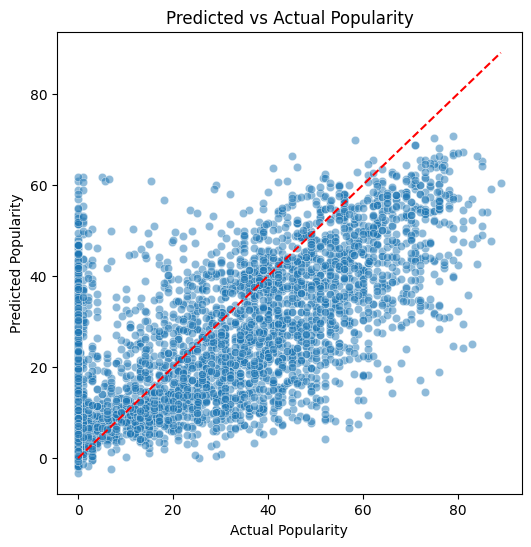

In [160]:
# --- Step 8: Train final model with best params ---
best_model = random_search.best_estimator_
best_model.fit(train_pool, eval_set=test_pool, verbose=100, early_stopping_rounds=50)

# --- Step 9: Predict and evaluate ---
y_pred = best_model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n📊 Regression Results:")
print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ R2 Score: {r2:.4f}")

# Optional: Plot predicted vs actual
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Predicted vs Actual Popularity")
plt.show()

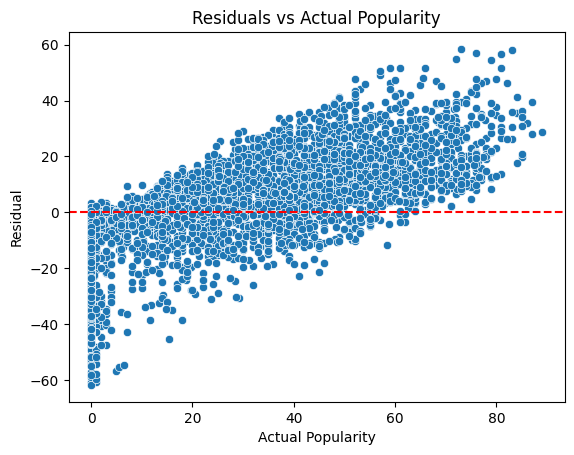

In [161]:
residuals = y_test - y_pred
sns.scatterplot(x=y_test, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Actual Popularity")
plt.ylabel("Residual")
plt.title("Residuals vs Actual Popularity")
plt.show()


In [162]:
# --- Step 10: Feature importance ---
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.get_feature_importance()
}).sort_values(by="Importance", ascending=False)

print("\n🔥 Top 10 Important Features:")
print(importances.head(10))


🔥 Top 10 Important Features:
                     Feature  Importance
16            artist_avg_pop   52.718651
0           track_album_name   13.392429
2   track_album_release_date    6.093612
17               release_age    4.686608
15                    period    4.117189
18         artist_song_count    3.446876
36             post-teen pop    1.793216
10          instrumentalness    1.079518
6                   loudness    1.050291
42        urban contemporary    1.035051


Fitting 3 folds for each of 6 candidates, totalling 18 fits
0:	learn: 1.8807869	total: 43.6ms	remaining: 17.4s
50:	learn: 1.4697829	total: 5.56s	remaining: 38s
100:	learn: 1.4360038	total: 11.4s	remaining: 33.8s
150:	learn: 1.4232692	total: 16.7s	remaining: 27.5s
200:	learn: 1.4081703	total: 21.8s	remaining: 21.6s
250:	learn: 1.3547342	total: 27s	remaining: 16s
300:	learn: 1.3250077	total: 32.6s	remaining: 10.7s
350:	learn: 1.2989825	total: 38.5s	remaining: 5.37s
399:	learn: 1.2747816	total: 44.4s	remaining: 0us
✅ Best Params: {'learning_rate': 0.03, 'l2_leaf_reg': 3, 'depth': 10}
📈 Best CV RMSE: 1.395378031118339
0:	learn: 1.8807869	test: 2.0439345	best: 2.0439345 (0)	total: 44.6ms	remaining: 17.8s
100:	learn: 1.4360038	test: 1.6054563	best: 1.6054563 (100)	total: 12.1s	remaining: 35.8s
200:	learn: 1.4081703	test: 1.5915547	best: 1.5915547 (200)	total: 22.7s	remaining: 22.5s
300:	learn: 1.3250077	test: 1.4867417	best: 1.4867417 (300)	total: 34.2s	remaining: 11.2s
399:	learn: 1.2747816

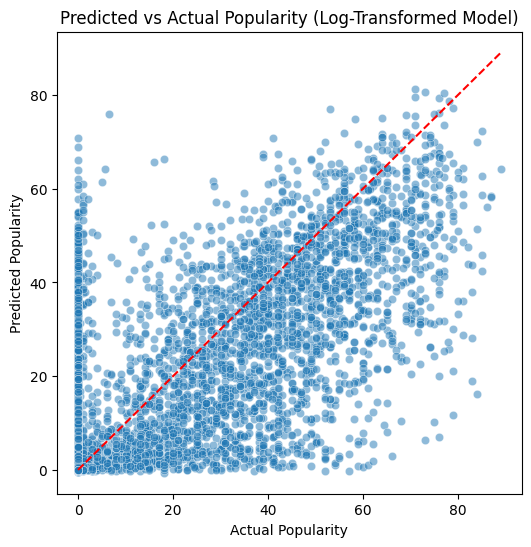

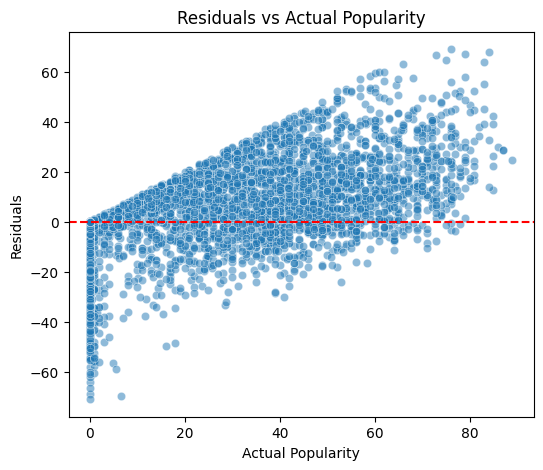

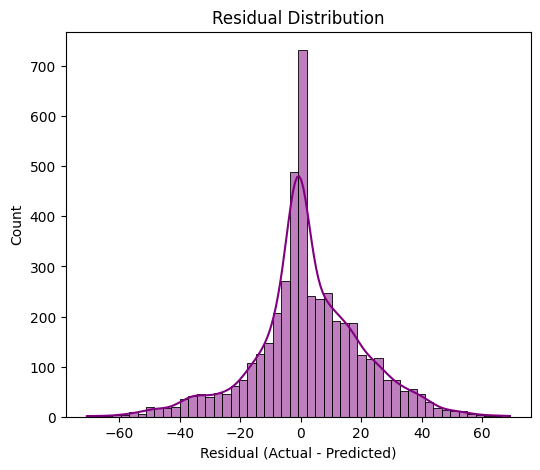


🔥 Top 10 Important Features:
                     Feature  Importance
16            artist_avg_pop   30.271310
18         artist_song_count    7.407776
2   track_album_release_date    6.151906
14                    season    5.177637
0           track_album_name    4.715266
10          instrumentalness    3.955614
17               release_age    3.720637
15                    period    3.605656
6                   loudness    3.055356
1                duration_ms    3.008782


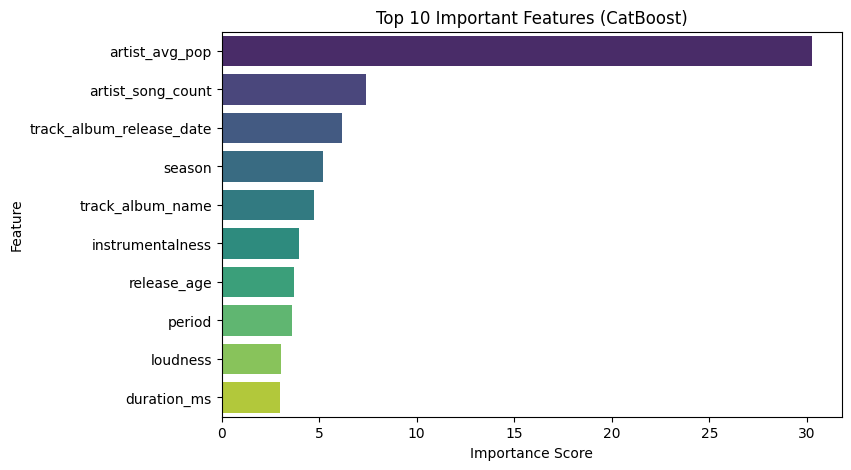

In [113]:
# --- Imports ---
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 0: Encode multi-label categorical features ---
df_mod = df_grouped.copy()

mlb_genre = MultiLabelBinarizer()
genres = df_mod["playlist_genre"].str.split("; ")
genre_encoded = mlb_genre.fit_transform(genres)
genre_df = pd.DataFrame(genre_encoded, columns=mlb_genre.classes_)
df_mod = pd.concat([df_mod.drop(columns=["playlist_genre"]), genre_df], axis=1)

mlb_sub = MultiLabelBinarizer()
subgenres = df_mod["playlist_subgenre"].str.split("; ")
subgenre_encoded = mlb_sub.fit_transform(subgenres)
subgenre_df = pd.DataFrame(subgenre_encoded, columns=mlb_sub.classes_)
df_mod = pd.concat([df_mod.drop(columns=["playlist_subgenre"]), subgenre_df], axis=1)

# --- Step 1: Define target and features ---
y = df_mod["popularity_2025"]
X = df_mod.drop(columns=[
    "popularity_2025",
    "popularity_2023",
    "popularity_categorized",
    "track_name",
    "track_id",
    "track_artist",
    "popularity_norm",
    "year"
], errors="ignore")

#add interaction features
X['energy_dance_ratio'] = X['energy'] / (X['danceability'] + 1e-6)
X['acoustic_loudness'] = X['acousticness'] * X['loudness']

# --- Step 2: Split data ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Step 3: Identify categorical and numeric features ---
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_features = X.select_dtypes(include=['number']).columns.tolist()

# --- Step 4: Handle missing values ---
for col in cat_features:
    X_train[col] = X_train[col].astype(str).fillna("Unknown")
    X_test[col] = X_test[col].astype(str).fillna("Unknown")

for col in num_features:
    X_train[col] = X_train[col].fillna(X_train[col].median())
    X_test[col] = X_test[col].fillna(X_train[col].median())

# --- Step 5: Log-transform target and create sample weights ---
# Helps stabilize variance and improve prediction of high-popularity tracks
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
sample_weights = 1 + (y_train / y_train.max())  # emphasize high-popularity songs

# --- Step 6: Define base model ---
base_model = CatBoostRegressor(
    loss_function='Quantile:alpha=0.5',
    eval_metric='RMSE',
    random_seed=42,
    iterations=400,
    early_stopping_rounds=50,
    verbose=50
)

# --- Step 7: Hyperparameter tuning using RandomizedSearchCV ---
param_dist = {
    'depth': [6, 8, 10],
    'learning_rate': [0.03, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=6,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train_log, cat_features=cat_features, sample_weight=sample_weights)

print("✅ Best Params:", random_search.best_params_)
print("📈 Best CV RMSE:", -random_search.best_score_)

# --- Step 8: Train final model with best params ---
best_model = random_search.best_estimator_
best_model.fit(
    X_train, y_train_log,
    cat_features=cat_features,
    eval_set=(X_test, y_test_log),
    sample_weight=sample_weights,
    verbose=100,
    early_stopping_rounds=50
)

# --- Step 9: Predict and inverse-transform predictions ---
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)  # inverse log1p

# --- Step 10: Evaluate ---
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n📊 Regression Results (Log-Transformed Model):")
print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ R² Score: {r2:.4f}")

# --- Step 11: Visualization ---

# 1️⃣ Predicted vs Actual
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Predicted vs Actual Popularity (Log-Transformed Model)")
plt.show()

# 2️⃣ Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(6,5))
sns.scatterplot(x=y_test, y=residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Actual Popularity")
plt.ylabel("Residuals")
plt.title("Residuals vs Actual Popularity")
plt.show()

# 3️⃣ Error Distribution
plt.figure(figsize=(6,5))
sns.histplot(residuals, bins=50, kde=True, color="purple")
plt.title("Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.show()

# --- Step 12: Feature Importance ---
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.get_feature_importance()
}).sort_values(by="Importance", ascending=False)

print("\n🔥 Top 10 Important Features:")
print(importances.head(10))

# --- Step 13: Plot Top Features ---
plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=importances.head(10), palette="viridis")
plt.title("Top 10 Important Features (CatBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

Classification

In [ ]:
# --- Imports ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# ---  Define target & features ---
df_mod = df_grouped.copy()

y = df_mod["popularity_categorized"]  # Categorical target
X = df_mod.drop(columns=[
    "popularity_2025",
    "popularity_2023",
    "popularity_categorized",
    "track_name",
    "track_id",
    "track_artist",
    "popularity_norm",
    "year",
    "track_album_release_date"
], errors="ignore")

# ---  Encode target ---
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ---  Split the dataset ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.1, random_state=42, stratify=y_encoded
)

# ---  Identify categorical & numeric features ---
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_features = X.select_dtypes(include=['number']).columns.tolist()

# ---  Handle missing values ---
for col in cat_features:
    X_train[col] = X_train[col].astype(str).fillna("Unknown")
    X_test[col] = X_test[col].astype(str).fillna("Unknown")

for col in num_features:
    X_train[col] = X_train[col].fillna(X_train[col].median())
    X_test[col] = X_test[col].fillna(X_train[col].median())

# ---  Preprocessing ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

In [ ]:
# --- Random Forest Classifier ---
rf = RandomForestClassifier(random_state=42,class_weight='balanced')
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', rf)])

param_grid_rf = {
    'model__n_estimators': [200,230,240],
    'model__max_depth': [8,10,12],
    'model__min_samples_split': [5, 10]
}

grid_rf = GridSearchCV(
    rf_pipeline, param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_rf.fit(X_train, y_train)

print("🔍 Best RF Parameters:", grid_rf.best_params_)
y_pred_rf = grid_rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)


Fitting 3 folds for each of 18 candidates, totalling 54 fits
🔍 Best RF Parameters: {'model__max_depth': 12, 'model__min_samples_split': 5, 'model__n_estimators': 230}


In [ ]:
# --- CatBoost Classifier ---
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    eval_metric='Accuracy',
    random_seed=42,
    auto_class_weights='Balanced',
    verbose=100
)
cat_model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test))
y_pred_cat = cat_model.predict(X_test)
acc_cat = accuracy_score(y_test, y_pred_cat)


0:	learn: 0.6264275	test: 0.6239041	best: 0.6239041 (0)	total: 112ms	remaining: 33.4s
100:	learn: 0.7018434	test: 0.6963733	best: 0.6994914 (73)	total: 9.91s	remaining: 19.5s
200:	learn: 0.7286858	test: 0.7077582	best: 0.7077582 (200)	total: 19.3s	remaining: 9.52s
299:	learn: 0.7582585	test: 0.7125681	best: 0.7167535 (279)	total: 28.8s	remaining: 0us

bestTest = 0.7167535209
bestIteration = 279

Shrink model to first 280 iterations.


In [ ]:
# ---  Neural Network (MLP) ---
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# 1️⃣ Identify categorical and numeric features
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()

# 2️⃣ Preprocess: OneHotEncode categorical + Scale numeric
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

# 3️⃣ Create pipeline with preprocessing, SMOTE, and MLP
mlp_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', MLPClassifier(max_iter=500, random_state=42))
])

# 4️⃣ Define hyperparameters
param_grid_mlp = {
    'model__hidden_layer_sizes': [ (50,), (100,), (100,50)],
    'model__activation': ['relu','tanh'],
    'model__alpha': [0.0001],
    'model__learning_rate_init': [0.001,0.01]
}

# 5️⃣ Grid Search
grid_mlp = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=param_grid_mlp,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("🚀 Training MLP with preprocessing + SMOTE...")
grid_mlp.fit(X_train, y_train)

# 6️⃣ Predictions
y_pred_mlp = grid_mlp.predict(X_test)
acc_mlp = accuracy_score(y_test, y_pred_mlp)

print(f"✅ Accuracy (MLP): {acc_mlp:.4f}")
print("🎯 Best Parameters:", grid_mlp.best_params_)


🚀 Training MLP with preprocessing + SMOTE...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
✅ Accuracy (MLP): 0.7016
🎯 Best Parameters: {'model__activation': 'relu', 'model__alpha': 0.0001, 'model__hidden_layer_sizes': (100, 50), 'model__learning_rate_init': 0.001}


In [61]:
# --- Logistic Regression ---
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', log_reg)
])

param_grid_logreg = {
    'model__C': [0.1, 1, 10],
    'model__solver': ['liblinear', 'lbfgs']
}

grid_logreg = GridSearchCV(
    logreg_pipeline,
    param_grid_logreg,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("🚀 Training Logistic Regression...")
grid_logreg.fit(X_train, y_train)
y_pred_logreg = grid_logreg.predict(X_test)
acc_logreg = accuracy_score(y_test, y_pred_logreg)
print(f"✅ Accuracy (Logistic Regression): {acc_logreg:.4f}")
print("🎯 Best Parameters:", grid_logreg.best_params_)


🚀 Training Logistic Regression...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
✅ Accuracy (Logistic Regression): 0.7420
🎯 Best Parameters: {'model__C': 10, 'model__solver': 'liblinear'}


In [ ]:
# ---  Print classification reports ---
print("\n📊 Random Forest Results:")
print("Accuracy:", round(acc_rf, 4))
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

print("\n📊 CatBoost Results:")
print("Accuracy:", round(acc_cat, 4))
print(classification_report(y_test, y_pred_cat, target_names=le.classes_))

print("\n📊 MLP Neural Network Results:")
print("Accuracy:", round(acc_mlp, 4))
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))

print("\n📊 Logistic Regression Results:")
print("Accuracy:", round(acc_logreg, 4))
print(classification_report(y_test, y_pred_logreg, target_names=le.classes_))


📊 Random Forest Results:
Accuracy: 0.6158
                     precision    recall  f1-score   support

             famous       0.43      0.33      0.37       601
hardly recognizable       0.80      0.72      0.76      1464
                hit       0.31      0.69      0.43       241

           accuracy                           0.62      2306
          macro avg       0.52      0.58      0.52      2306
       weighted avg       0.66      0.62      0.63      2306


📊 CatBoost Results:
Accuracy: 0.729
                     precision    recall  f1-score   support

             famous       0.55      0.64      0.59       601
hardly recognizable       0.89      0.76      0.82      1464
                hit       0.50      0.75      0.60       241

           accuracy                           0.73      2306
          macro avg       0.65      0.72      0.67      2306
       weighted avg       0.76      0.73      0.74      2306


📊 MLP Neural Network Results:
Accuracy: 0.7016
            

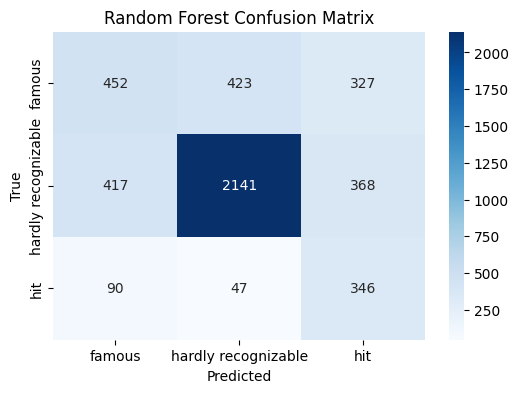

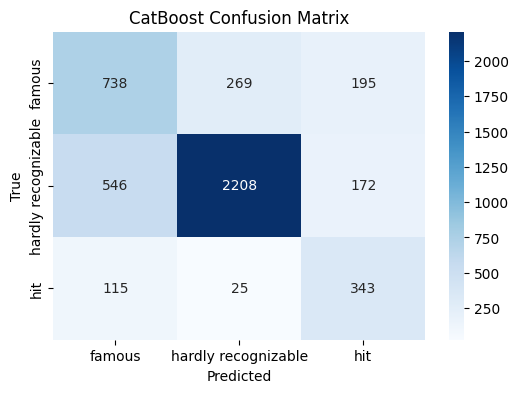

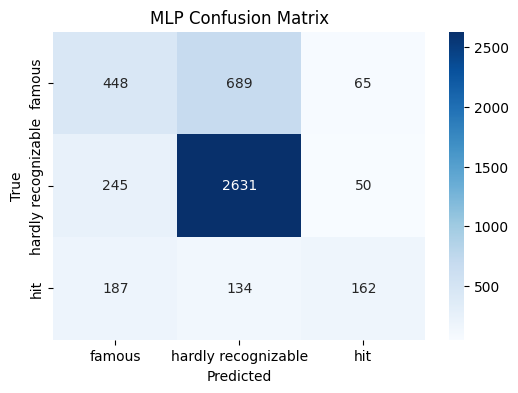

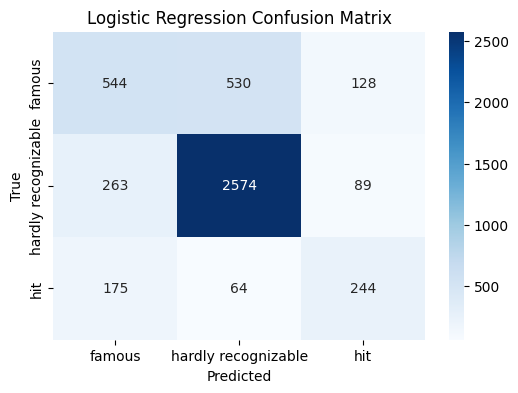

In [ ]:
# ---  Confusion Matrix Visualizations ---
models_preds = {
    "Random Forest": y_pred_rf,
    "CatBoost": y_pred_cat,
    "MLP": y_pred_mlp,
    "Logistic Regression":y_pred_logreg
}

for model_name, y_pred in models_preds.items():
    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


In [ ]:

# ---  Feature Importance for Random Forest & CatBoost ---

# Extract feature names after preprocessing
preprocessor_step = grid_rf.best_estimator_.named_steps['preprocessor']

# If using ColumnTransformer:
def get_feature_names(column_transformer):
    feature_names = []
    for name, transformer, cols in column_transformer.transformers_:
        if name != 'remainder':
            if hasattr(transformer, 'get_feature_names_out'):
                names = transformer.get_feature_names_out(cols)
            else:
                names = cols
            feature_names.extend(names)
    return feature_names

feature_names = get_feature_names(preprocessor_step)

importances_rf = pd.DataFrame({
    "Feature": feature_names,
    "Importance": grid_rf.best_estimator_.named_steps['model'].feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n🔥 Random Forest Top 10 Features:")
importances_rf.head(10)




🔥 Random Forest Top 10 Features:


,Feature,Importance
12,artist_avg_pop,0.212972
13,release_age,0.064774
14,artist_song_count,0.064362
8,instrumentalness,0.048975
0,duration_ms,0.034126
4,loudness,0.031626
15,playlist_genre_edm,0.031352
10,valence,0.030896
6,speechiness,0.030108
7,acousticness,0.029759


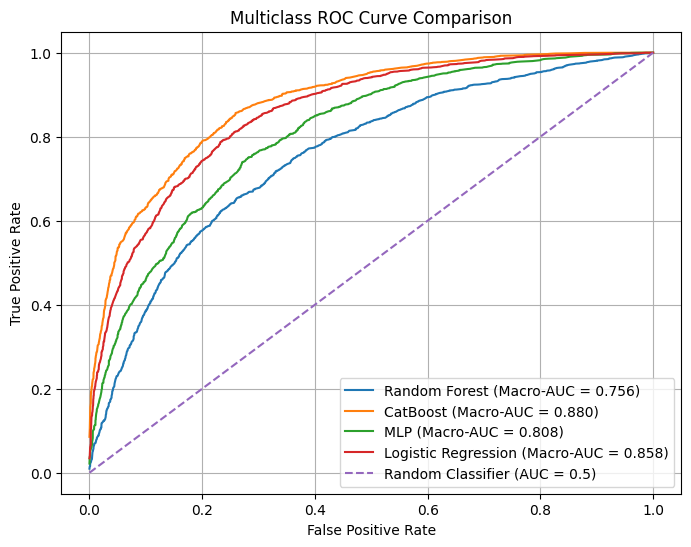

In [ ]:
#Plot ROC Curve
models = {
    "Random Forest": grid_rf,
    "CatBoost": cat_model,
    "MLP": grid_mlp,
    "Logistic Regression":grid_logreg
}
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Binarize the target for multiclass ROC
classes = list(set(y_test))
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(8, 6))

for name, model in models.items():
    # Get probability scores
    try:
        y_scores = model.predict_proba(X_test)
    except:
        y_scores = model.decision_function(X_test)

    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Macro-average AUC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes

    fpr_macro = all_fpr
    tpr_macro = mean_tpr
    roc_auc_macro = auc(fpr_macro, tpr_macro)

    plt.plot(fpr_macro, tpr_macro, label=f'{name} (Macro-AUC = {roc_auc_macro:.3f})')

# Plot random classifier line
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier (AUC = 0.5)')

plt.title('Multiclass ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
